<a href="https://colab.research.google.com/github/mohiuddin2806-lang/machine-learning-/blob/main/projectgroup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pyspark

In [2]:
import os
import math
import json
import time
import glob
import gc
import shutil
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark import StorageLevel
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import (
    StringIndexer,
    Imputer,
    VectorAssembler,
    StandardScaler,
    StandardScalerModel,
    PCA,
    PCAModel
)
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    DecisionTreeClassificationModel,
    RandomForestClassifier,
    RandomForestClassificationModel
)
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.functions import vector_to_array

SEED = 42

# A standard Colab runtime has limited RAM. The project uses two local
# Spark workers, disk-backed caching and sequential tuning to avoid the
# runtime being terminated by simultaneous Random Forest fits.
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("CN7030_CICIDS2017_Multiclass")
    .config("spark.driver.memory", "5g")
    .config("spark.driver.maxResultSize", "1g")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.default.parallelism", "64")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Python version:", platform.python_version())
print("Application:", spark.sparkContext.appName)


Spark version: 4.0.4
Python version: 3.12.13
Application: CN7030_CICIDS2017_Multiclass


In [3]:
from google.colab import drive
drive.mount("/content/drive")

# ------------------------------------------------------------------
# PROJECT MODE
# ------------------------------------------------------------------
# "TRAIN" performs the complete project and saves everything to Drive.
# "LOAD" restores the saved models, tables and figures without retraining.
PROJECT_MODE = "LOAD"
PROJECT_MODE = PROJECT_MODE.strip().upper()
if PROJECT_MODE not in {"TRAIN", "LOAD"}:
    raise ValueError("PROJECT_MODE must be TRAIN or LOAD.")
LOAD_SAVED_RESULTS_ONLY = PROJECT_MODE == "TRAIN"


# ------------------------------------------------------------------
# GROUP AND SUBMISSION DETAILS
# ------------------------------------------------------------------
# Replace these placeholders before creating the final HTML report.
GROUP_NUMBER = "10"
GROUP_MEMBER_COUNT = 4
STUDENT_DETAILS = [
    {
        "name": "Md Gulam Kibria Chowdhury",
        "student_id": "3242898"
    },
     {
        "name": "Ali Shreif",
        "student_id": "2906577"
    },
    {
        "name": "Mohammed Mohi Uddin",
        "student_id": "2975262"
    },
    {
        "name": "Thanushma Kuram",
        "student_id": "3120925"
    }
]
FINAL_HTML_FILENAME = (
    f"Group{GROUP_NUMBER}_CRWK_CN7030_{GROUP_MEMBER_COUNT}.html"
)

# ------------------------------------------------------------------
# DATASET CONFIGURATION
# ------------------------------------------------------------------
DATA_PATH = "/content/cicids2017_cleaned.csv"
TARGET_NAME = "Attack Type"

# ===============================
# DATASET INFORMATION
# ===============================

DATASET_TITLE = (
    "Cleaned and Preprocessed CICIDS2017 "
    "Network Intrusion Detection Dataset"
)

DATASET_SOURCE_URL = (
    "https://www.kaggle.com/datasets/"
    "ericanacletoribeiro/"
    "cicids2017-cleaned-and-preprocessed"
)

DATASET_DOWNLOAD_DATE = "2026-08-20"

TRAIN_RATIO = 0.80
TEST_RATIO = 0.20

# Optional repeated full experiments. Cross-validation mean ± standard
# deviation is always produced, so the coursework requirement is met even
# when these extra full repetitions are disabled for runtime safety.
RUN_REPEATED_EVALUATION = False
REPEATED_SEEDS = [42, 52, 62, 72, 82]

# Runtime-safe, genuine 3-fold hyperparameter tuning.
CV_FOLDS = 3
CV_MAX_ROWS = 75_000

# Clustering and visualisation limits.
CLUSTER_MAX_ROWS = 150_000
TOP_FEATURES_TO_PLOT = 20
ALL_FEATURE_SAMPLE_ROWS = 5_000
FEATURES_PER_VISUAL_PAGE = 12
CLASS_HEATMAP_FEATURES_PER_PAGE = 30
MAX_CORRELATION_FEATURES = 100
PCA_VISUAL_SAMPLE_ROWS = 5_000

# Copy the uploaded CSV to Drive so the project is persistent.
COPY_DATASET_TO_DRIVE = True

# ------------------------------------------------------------------
# PERMANENT PROJECT STORAGE
# ------------------------------------------------------------------
PROJECT_ROOT = "/content/drive/MyDrive/CN7030_CourseWork2"
DATA_DIR = f"{PROJECT_ROOT}/data"
MODELS_DIR = f"{PROJECT_ROOT}/models"
RESULTS_OUTPUT_PATH = f"{PROJECT_ROOT}/results"
FIGURES_DIR = f"{PROJECT_ROOT}/figures"
ALL_FEATURE_FIGURES_DIR = f"{FIGURES_DIR}/all_features"
METADATA_DIR = f"{PROJECT_ROOT}/metadata"

PREPROCESSING_MODEL_PATH = f"{MODELS_DIR}/preprocessing_pipeline"
DECISION_TREE_MODEL_PATH = f"{MODELS_DIR}/decision_tree"
MODEL_OUTPUT_PATH = f"{MODELS_DIR}/best_random_forest"
SCALER_MODEL_PATH = f"{MODELS_DIR}/kmeans_scaler"
PCA_MODEL_PATH = f"{MODELS_DIR}/kmeans_pca"
KMEANS_MODEL_PATH = f"{MODELS_DIR}/kmeans"

EXPERIMENT_SUMMARY_PATH = f"{METADATA_DIR}/experiment_summary.json"
EXPERIMENT_CONFIGURATION_PATH = f"{METADATA_DIR}/experiment_configuration.json"
FIGURE_MANIFEST_PATH = f"{METADATA_DIR}/figure_manifest.json"
SUCCESS_MARKER_PATH = f"{PROJECT_ROOT}/TRAINING_COMPLETE.txt"
README_PATH = f"{PROJECT_ROOT}/README_PROJECT.txt"

for directory in [
    PROJECT_ROOT,
    DATA_DIR,
    MODELS_DIR,
    RESULTS_OUTPUT_PATH,
    FIGURES_DIR,
    ALL_FEATURE_FIGURES_DIR,
    METADATA_DIR
]:
    os.makedirs(directory, exist_ok=True)

PERSISTENT_DATA_PATH = f"{DATA_DIR}/cicids2017_cleaned.csv"

print("Project mode:", PROJECT_MODE)
print("Final HTML filename:", FINAL_HTML_FILENAME)
print("Dataset path:", DATA_PATH)
print("Permanent project folder:", PROJECT_ROOT)
print("Load saved results only:", LOAD_SAVED_RESULTS_ONLY)

Mounted at /content/drive
Project mode: LOAD
Final HTML filename: Group10_CRWK_CN7030_4.html
Dataset path: /content/cicids2017_cleaned.csv
Permanent project folder: /content/drive/MyDrive/CN7030_CourseWork2
Load saved results only: False


In [4]:
if LOAD_SAVED_RESULTS_ONLY:
    if not os.path.exists(SUCCESS_MARKER_PATH):
        raise FileNotFoundError(
            "No completed saved experiment was found. "
            "Set PROJECT_MODE='TRAIN' and run the notebook once."
        )

    with open(
        EXPERIMENT_CONFIGURATION_PATH,
        "r",
        encoding="utf-8"
    ) as configuration_file:
        experiment_configuration = json.load(configuration_file)

    with open(
        EXPERIMENT_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as summary_file:
        saved_summary = json.load(summary_file)

    preprocessing_model = PipelineModel.load(PREPROCESSING_MODEL_PATH)
    decision_tree_model = DecisionTreeClassificationModel.load(
        DECISION_TREE_MODEL_PATH
    )
    best_random_forest = RandomForestClassificationModel.load(
        MODEL_OUTPUT_PATH
    )
    scaler_model = StandardScalerModel.load(SCALER_MODEL_PATH)
    pca_model = PCAModel.load(PCA_MODEL_PATH)
    kmeans_model = KMeansModel.load(KMEANS_MODEL_PATH)

    def load_csv_if_present(filename, **kwargs):
        path = f"{RESULTS_OUTPUT_PATH}/{filename}"
        return pd.read_csv(path, **kwargs) if os.path.exists(path) else None

    model_comparison = load_csv_if_present("model_comparison.csv")
    tuning_results = load_csv_if_present("random_forest_tuning_results.csv")
    cv_fold_results = load_csv_if_present("random_forest_cv_fold_results.csv")
    rf_per_class = load_csv_if_present(
        "random_forest_per_class_metrics.csv"
    )
    rf_matrix = load_csv_if_present(
        "random_forest_confusion_matrix.csv",
        index_col=0
    )
    feature_importance = load_csv_if_present("feature_importance.csv")
    bias_variance_table = load_csv_if_present(
        "bias_variance_analysis.csv"
    )
    class_distribution = load_csv_if_present("class_distribution.csv")
    missing_summary = load_csv_if_present("missing_value_summary.csv")
    all_feature_profile = load_csv_if_present("all_feature_profile.csv")
    all_feature_correlation = load_csv_if_present(
        "all_feature_correlation.csv",
        index_col=0
    )
    class_feature_medians = load_csv_if_present(
        "class_feature_medians.csv",
        index_col=0
    )
    cluster_class_pd = load_csv_if_present(
        "cluster_class_comparison.csv"
    )
    kmeans_search_results = load_csv_if_present("kmeans_k_search.csv")
    repeated_results_df = load_csv_if_present("repeated_seed_results.csv")
    cv_mean_std_table = load_csv_if_present(
        "cv_mean_and_standard_deviation.csv"
    )
    repeated_mean_std_table = load_csv_if_present(
        "repeated_mean_and_standard_deviation.csv"
    )

    label_names = experiment_configuration["class_names"]
    feature_cols = experiment_configuration["feature_columns"]
    number_of_labels = experiment_configuration["number_of_classes"]
    BEST_NUM_TREES = experiment_configuration["best_num_trees"]
    BEST_MAX_DEPTH = experiment_configuration["best_max_depth"]
    BEST_MIN_INSTANCES = experiment_configuration.get(
        "best_min_instances_per_node",
        1
    )
    BEST_SUBSAMPLING_RATE = experiment_configuration.get(
        "best_subsampling_rate",
        0.8
    )
    BEST_MAX_BINS = experiment_configuration.get("best_max_bins", 32)
    BEST_K = saved_summary["best_kmeans_k"]
    silhouette_score = saved_summary["kmeans_silhouette"]
    rf_summary = saved_summary["random_forest_summary"]
    dt_summary = saved_summary["decision_tree_summary"]
    cleaned_row_count = int(saved_summary["cleaned_rows"])

    print("=" * 76)
    print("SAVED CN7030 PROJECT LOADED — NO RETRAINING WAS PERFORMED")
    print("=" * 76)
    print("Saved on:", saved_summary["saved_at"])
    print("Cleaned rows:", f"{cleaned_row_count:,}")
    print("Usable numerical features:", len(feature_cols))
    print("Classes:", number_of_labels)
    print("Best RF trees:", BEST_NUM_TREES)
    print("Best RF depth:", BEST_MAX_DEPTH)
    print("Best RF minimum node instances:", BEST_MIN_INSTANCES)
    print("Random Forest weighted F1:", f"{rf_summary['weighted_f1']:.4f}")
    print("Best K-Means K:", BEST_K)
    print("K-Means silhouette:", f"{silhouette_score:.4f}")
    print("=" * 76)

    for table_name, table_value in [
        ("Model comparison", model_comparison),
        ("Hyperparameter tuning", tuning_results),
        ("Random Forest per-class metrics", rf_per_class),
        ("All-feature profile", all_feature_profile)
    ]:
        if table_value is not None:
            print(f"\n{table_name}:")
            display(table_value.head(100))

    from IPython.display import display as ipy_display, Image

    saved_figure_paths = sorted(
        glob.glob(f"{FIGURES_DIR}/**/*.png", recursive=True)
    )

    print(f"\nSaved figures found: {len(saved_figure_paths)}")
    for figure_path in saved_figure_paths:
        print(os.path.relpath(figure_path, PROJECT_ROOT))
        ipy_display(Image(filename=figure_path))

    print(
        "\nLoad mode is complete. All training and preprocessing sections "
        "below are automatically skipped."
    )
else:
    print(
        "Full-training mode is active. Continue through the notebook. "
        "The final saving section will store every model, table and figure."
    )


Full-training mode is active. Continue through the notebook. The final saving section will store every model, table and figure.


In [7]:
if not LOAD_SAVED_RESULTS_ONLY:
    # Resolve the dataset from the upload area or the permanent Drive copy.
    candidate_dataset_paths = [
        DATA_PATH,
        PERSISTENT_DATA_PATH,
        "/content/drive/MyDrive/cicids2017_cleaned.csv"
    ]

    resolved_dataset_path = next(
        (
            candidate_path
            for candidate_path in candidate_dataset_paths
            if candidate_path and os.path.exists(candidate_path)
        ),
        None
    )

    if resolved_dataset_path is None:
        from google.colab import files as colab_files

        print(
            "Dataset not found. Select the CICIDS2017 cleaned CSV "
            "using the upload window."
        )

        uploaded_files = colab_files.upload()

        uploaded_csv_files = [
            filename
            for filename in uploaded_files
            if filename.lower().endswith(".csv")
        ]

        if not uploaded_csv_files:
            raise FileNotFoundError(
                "No CSV file was uploaded. "
                "Upload the cleaned CICIDS2017 CSV."
            )

        resolved_dataset_path = os.path.join(
            "/content",
            uploaded_csv_files[0]
        )

    DATA_PATH = resolved_dataset_path

    # Copy the dataset to Google Drive so it remains available
    # after the Colab session ends.
    if COPY_DATASET_TO_DRIVE and DATA_PATH != PERSISTENT_DATA_PATH:
        persistent_directory = os.path.dirname(PERSISTENT_DATA_PATH)

        if persistent_directory:
            os.makedirs(persistent_directory, exist_ok=True)

        if not os.path.exists(PERSISTENT_DATA_PATH):
            shutil.copy2(DATA_PATH, PERSISTENT_DATA_PATH)
            print(
                "Dataset copied permanently to:",
                PERSISTENT_DATA_PATH
            )
        else:
            print(
                "Permanent dataset copy already exists:",
                PERSISTENT_DATA_PATH
            )
        # Fix: Update DATA_PATH to the persistent location after copying or confirming its existence
        DATA_PATH = PERSISTENT_DATA_PATH

    # Calculate the dataset size only after confirming the file exists.
    dataset_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)

    print("Dataset title:", DATASET_TITLE)
    print("Dataset source:", DATASET_SOURCE_URL)
    print("Download date:", DATASET_DOWNLOAD_DATE)
    print("Resolved CSV path:", DATA_PATH)
    print(f"CSV file size: {dataset_size_mb:.2f} MB")

    # Check the coursework recommended size.
    if 300 <= dataset_size_mb <= 1024:
        print(
            "Dataset size is inside the coursework ideal range."
        )
    else:
        print(
            "WARNING: the dataset is outside the ideal "
            "300 MB–1 GB range. Explain and justify the "
            "selected dataset size in the report."
        )

    # Check whether the dataset reference details were completed.
    if (
        "PASTE_THE_EXACT" in DATASET_SOURCE_URL
        or DATASET_DOWNLOAD_DATE == "YYYY-MM-DD"
    ):
        print(
            "WARNING: complete DATASET_SOURCE_URL and "
            "DATASET_DOWNLOAD_DATE before submission."
        )

    # Read the CSV into a Spark DataFrame.
    raw_df = spark.read.csv(
        DATA_PATH,
        header=True,
        inferSchema=True,
        mode="PERMISSIVE"
    )

    # Remove accidental spaces from column names.
    for old_name in raw_df.columns:
        new_name = old_name.strip()

        if old_name != new_name:
            raw_df = raw_df.withColumnRenamed(
                old_name,
                new_name
            )

    raw_row_count = raw_df.count()

    print(f"Rows: {raw_row_count:,}")
    print(f"Columns: {len(raw_df.columns)}")

    raw_df.show(5, truncate=False)

else:
    print(
        "LOAD_SAVED_RESULTS_ONLY is enabled. "
        "Dataset loading and processing were skipped."
    )

Permanent dataset copy already exists: /content/drive/MyDrive/CN7030_CourseWork2/data/cicids2017_cleaned.csv
Dataset title: Cleaned and Preprocessed CICIDS2017 Network Intrusion Detection Dataset
Dataset source: https://www.kaggle.com/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed
Download date: 2026-08-20
Resolved CSV path: /content/drive/MyDrive/CN7030_CourseWork2/data/cicids2017_cleaned.csv
CSV file size: 684.02 MB
Dataset size is inside the coursework ideal range.
Rows: 2,520,751
Columns: 53
+----------------+-------------+-----------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+--------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-----------------+

,measurement,value
0,Rows,2.520751e+06
1,Columns,5.300000e+01
2,File size (MB),6.840206e+02


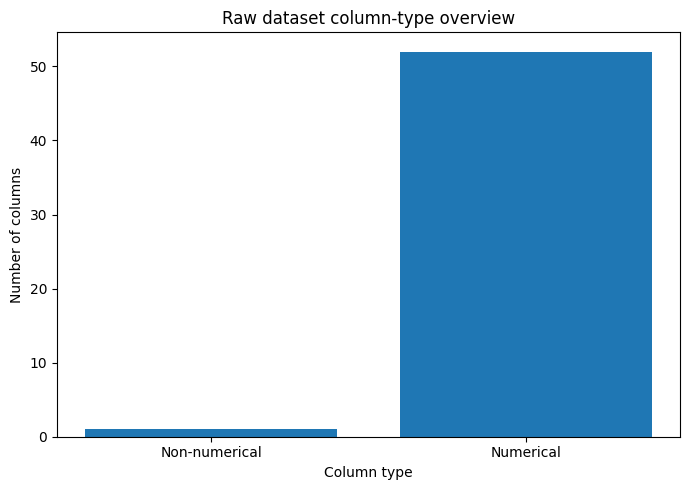

In [8]:
if not LOAD_SAVED_RESULTS_ONLY:
    dataset_overview = pd.DataFrame({
        "measurement": [
            "Rows",
            "Columns",
            "File size (MB)"
        ],
        "value": [
            raw_df.count(),
            len(raw_df.columns),
            dataset_size_mb
        ]
    })

    display(dataset_overview)

    type_summary = pd.DataFrame(
        raw_df.dtypes,
        columns=["column", "spark_type"]
    )

    type_summary["type_group"] = np.where(
        type_summary["spark_type"].isin([
            "tinyint", "smallint", "int", "bigint",
            "float", "double", "decimal"
        ]),
        "Numerical",
        "Non-numerical"
    )

    type_counts = (
        type_summary
        .groupby("type_group")
        .size()
        .reset_index(name="column_count")
    )

    plt.figure(figsize=(7, 5))
    plt.bar(type_counts["type_group"], type_counts["column_count"])
    plt.xlabel("Column type")
    plt.ylabel("Number of columns")
    plt.title("Raw dataset column-type overview")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/01_raw_column_types.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    type_summary.to_csv(
        f"{RESULTS_OUTPUT_PATH}/raw_column_type_summary.csv",
        index=False
    )
else:
    pass


In [9]:
if not LOAD_SAVED_RESULTS_ONLY:
    # Resolve the target even if its capitalisation differs slightly.
    matching_targets = [
        c for c in raw_df.columns
        if c.strip().lower() == TARGET_NAME.strip().lower()
    ]

    if not matching_targets:
        raise ValueError(
            f"Target '{TARGET_NAME}' was not found. "
            f"Available columns include: {raw_df.columns[:20]}"
        )

    TARGET_COL = matching_targets[0]

    raw_df.printSchema()

    number_of_classes = (
        raw_df.select(TARGET_COL)
        .where(F.col(TARGET_COL).isNotNull())
        .distinct()
        .count()
    )

    print("Resolved target:", TARGET_COL)
    print("Number of target classes:", number_of_classes)

    if number_of_classes < 3:
        raise ValueError(
            "This coursework requires multiclass data, but fewer than three classes were found."
        )
else:
    pass

root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: integer (nullable = true)
 |-- Flow IAT Min: integer (nullable = true)
 |-- Fwd IAT Total: integer (nullable = true)
 |-- Fwd IAT Mean: double (nullable = true)
 

In [10]:
if not LOAD_SAVED_RESULTS_ONLY:
    clean_df = (
        raw_df
        .filter(F.col(TARGET_COL).isNotNull())
        .filter(F.length(F.trim(F.col(TARGET_COL).cast("string"))) > 0)
    )

    rows_before_duplicates = clean_df.count()

    clean_df = clean_df.dropDuplicates().persist(
        StorageLevel.MEMORY_AND_DISK
    )

    rows_after_duplicates = clean_df.count()
    cleaned_row_count = rows_after_duplicates

    print(f"Rows before exact duplicate removal: {rows_before_duplicates:,}")
    print(f"Rows after exact duplicate removal:  {rows_after_duplicates:,}")
    print(f"Exact duplicates removed: {rows_before_duplicates - rows_after_duplicates:,}")
else:
    pass


Rows before exact duplicate removal: 2,520,751
Rows after exact duplicate removal:  2,520,590
Exact duplicates removed: 161


,stage,records
0,Before duplicate removal,2520751
1,After duplicate removal,2520590
2,Duplicates removed,161


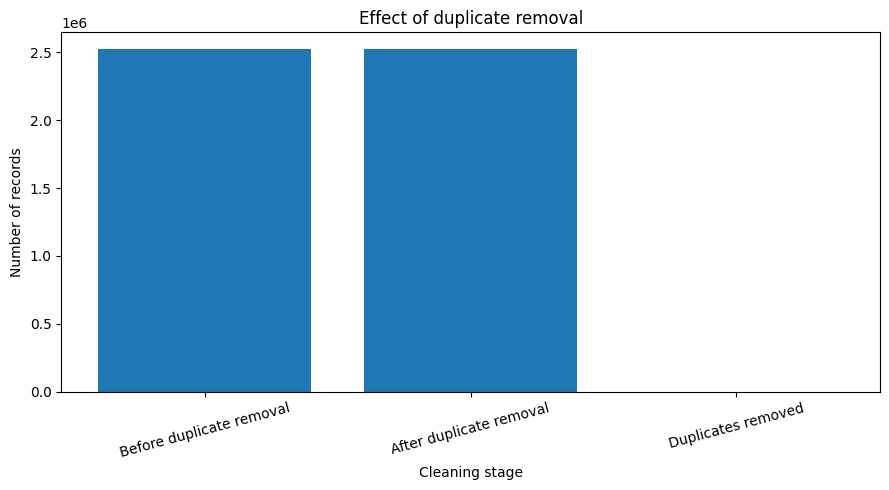

Percentage of duplicate rows removed: 0.0064%


In [11]:
if not LOAD_SAVED_RESULTS_ONLY:
    cleaning_impact = pd.DataFrame({
        "stage": [
            "Before duplicate removal",
            "After duplicate removal",
            "Duplicates removed"
        ],
        "records": [
            rows_before_duplicates,
            rows_after_duplicates,
            rows_before_duplicates - rows_after_duplicates
        ]
    })

    display(cleaning_impact)

    plt.figure(figsize=(9, 5))
    plt.bar(cleaning_impact["stage"], cleaning_impact["records"])
    plt.xlabel("Cleaning stage")
    plt.ylabel("Number of records")
    plt.title("Effect of duplicate removal")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/02_cleaning_impact.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    duplicate_percentage = (
        100.0
        * (rows_before_duplicates - rows_after_duplicates)
        / max(rows_before_duplicates, 1)
    )

    print(f"Percentage of duplicate rows removed: {duplicate_percentage:.4f}%")
else:
    pass


In [12]:
if not LOAD_SAVED_RESULTS_ONLY:
    KNOWN_IDENTIFIER_COLUMNS = {
        "flow id",
        "src ip",
        "source ip",
        "dst ip",
        "destination ip",
        "timestamp"
    }

    candidate_features = [
        c for c in clean_df.columns
        if c != TARGET_COL
        and c.strip().lower() not in KNOWN_IDENTIFIER_COLUMNS
    ]

    for c in candidate_features:
        clean_df = clean_df.withColumn(
            c,
            F.expr(f"try_cast(`{c}` as double)")
        )

    for c in candidate_features:
        clean_df = clean_df.withColumn(
            c,
            F.when(
                F.isnan(F.col(c))
                | (F.col(c) == float("inf"))
                | (F.col(c) == float("-inf")),
                F.lit(None).cast(DoubleType())
            ).otherwise(F.col(c))
        )

    # Count valid numerical values in one distributed aggregation.
    non_null_counts = (
        clean_df
        .select([
            F.count(F.col(c)).alias(c)
            for c in candidate_features
        ])
        .first()
        .asDict()
    )

    feature_cols = [
        c for c in candidate_features
        if non_null_counts.get(c, 0) > 0
    ]

    dropped_non_numeric = [
        c for c in candidate_features
        if c not in feature_cols
    ]

    clean_df = clean_df.select(TARGET_COL, *feature_cols)

    print("Usable numerical features:", len(feature_cols))
    print("Dropped non-numerical or empty columns:", dropped_non_numeric)

    if not feature_cols:
        raise ValueError("No usable numerical feature columns were found.")
else:
    pass


Usable numerical features: 52
Dropped non-numerical or empty columns: []


,category,column_count
0,Usable numerical features,52
1,Dropped non-numerical/empty,0
2,Excluded identifiers,0
3,Target column,1


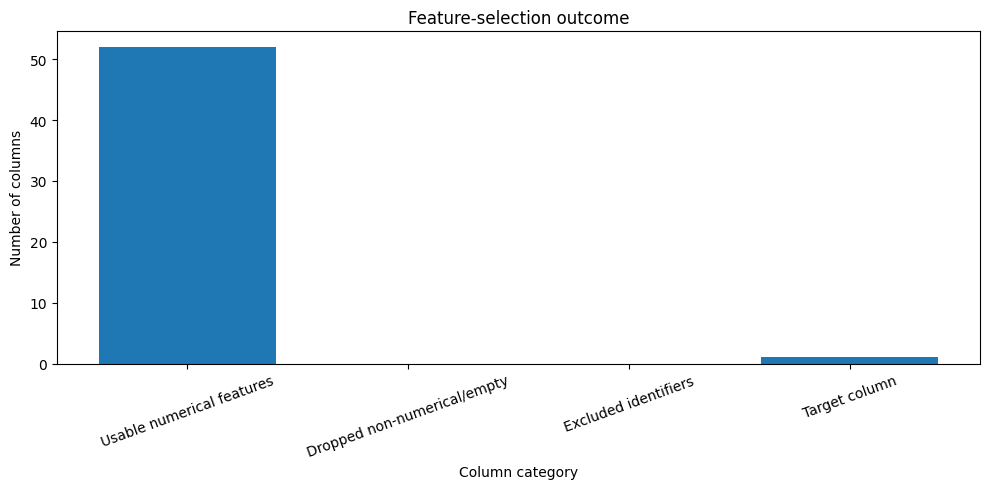

In [13]:
if not LOAD_SAVED_RESULTS_ONLY:
    identifier_columns_found = [
        c for c in raw_df.columns
        if c.strip().lower() in KNOWN_IDENTIFIER_COLUMNS
    ]

    feature_selection_summary = pd.DataFrame({
        "category": [
            "Usable numerical features",
            "Dropped non-numerical/empty",
            "Excluded identifiers",
            "Target column"
        ],
        "column_count": [
            len(feature_cols),
            len(dropped_non_numeric),
            len(identifier_columns_found),
            1
        ]
    })

    display(feature_selection_summary)

    plt.figure(figsize=(10, 5))
    plt.bar(
        feature_selection_summary["category"],
        feature_selection_summary["column_count"]
    )
    plt.xlabel("Column category")
    plt.ylabel("Number of columns")
    plt.title("Feature-selection outcome")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/03_feature_selection_summary.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


+--------------+-------+
|Attack Type   |count  |
+--------------+-------+
|Normal Traffic|2094896|
|DoS           |193745 |
|DDoS          |128014 |
|Port Scanning |90694  |
|Brute Force   |9150   |
|Web Attacks   |2143   |
|Bots          |1948   |
+--------------+-------+



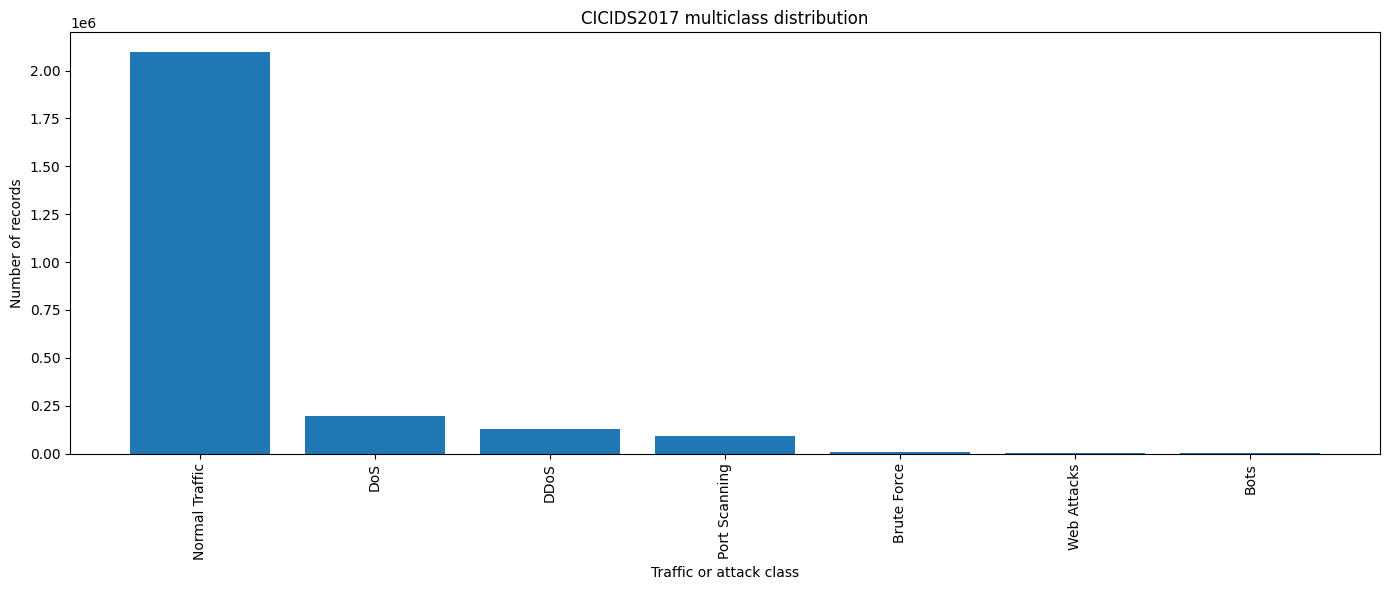

Imbalance ratio (largest / smallest class): 1075.41


In [14]:
if not LOAD_SAVED_RESULTS_ONLY:
    class_distribution_spark = (
        clean_df
        .groupBy(TARGET_COL)
        .count()
        .orderBy(F.desc("count"))
    )

    class_distribution_spark.show(100, truncate=False)

    class_distribution = class_distribution_spark.toPandas()

    plt.figure(figsize=(14, 6))
    plt.bar(class_distribution[TARGET_COL], class_distribution["count"])
    plt.xticks(rotation=90)
    plt.xlabel("Traffic or attack class")
    plt.ylabel("Number of records")
    plt.title("CICIDS2017 multiclass distribution")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/class_distribution.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    class_distribution.to_csv(
        f"{RESULTS_OUTPUT_PATH}/class_distribution.csv",
        index=False
    )

    imbalance_ratio = (
        class_distribution["count"].max()
        / class_distribution["count"].min()
    )

    print(f"Imbalance ratio (largest / smallest class): {imbalance_ratio:.2f}")
else:
    pass


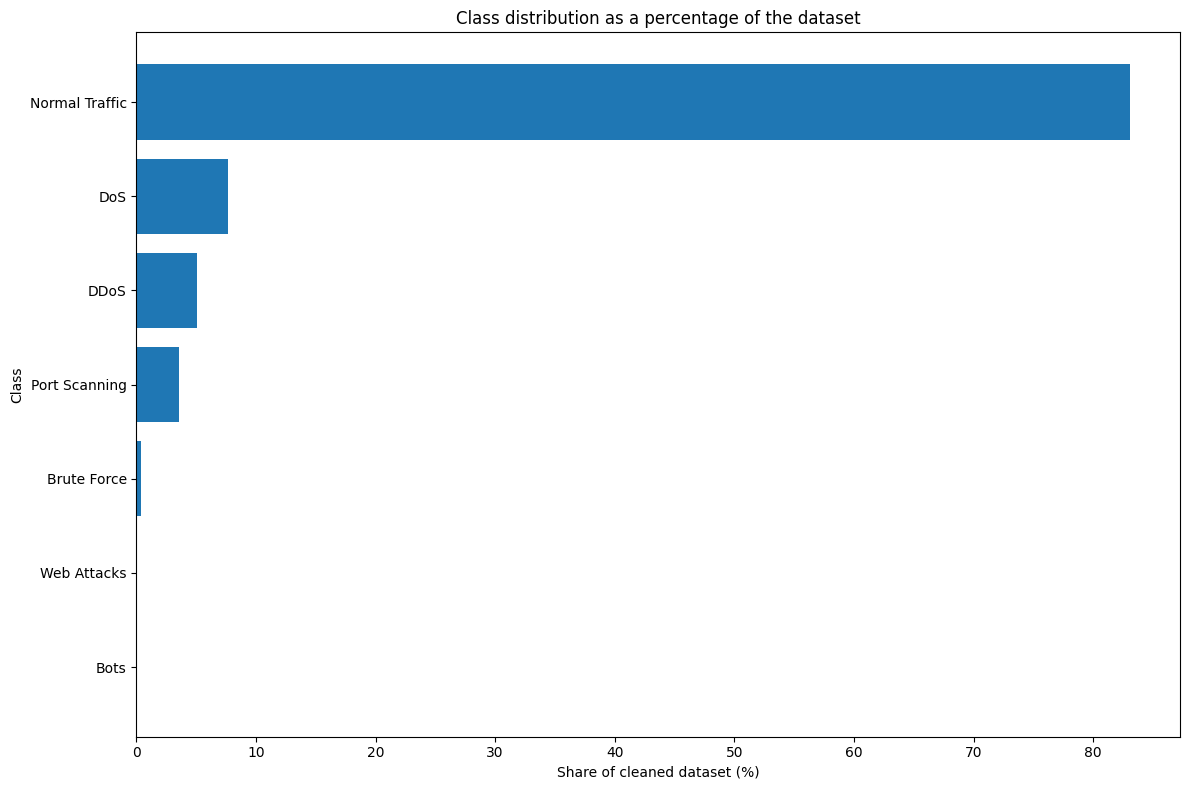

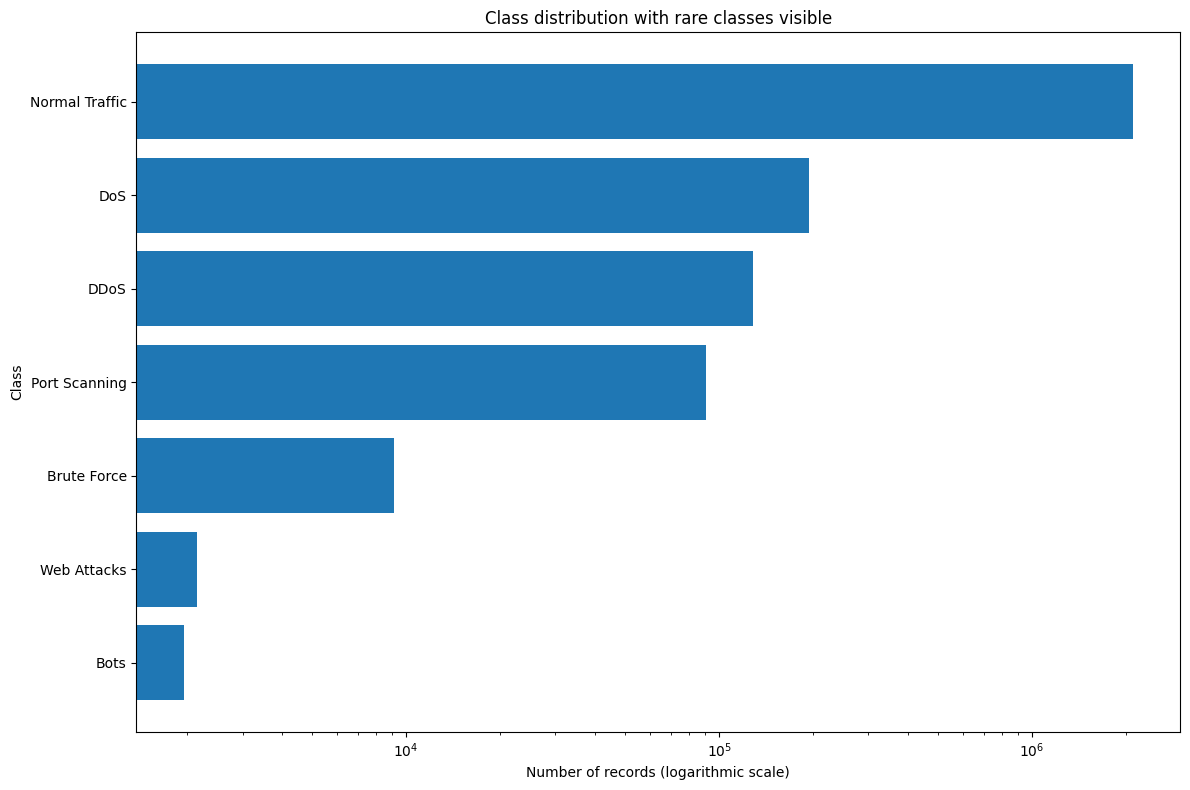

In [15]:
if not LOAD_SAVED_RESULTS_ONLY:
    class_distribution["percentage"] = (
        100.0
        * class_distribution["count"]
        / class_distribution["count"].sum()
    )

    class_percentage_view = (
        class_distribution
        .sort_values("percentage", ascending=True)
    )

    plt.figure(figsize=(12, 8))
    plt.barh(
        class_percentage_view[TARGET_COL],
        class_percentage_view["percentage"]
    )
    plt.xlabel("Share of cleaned dataset (%)")
    plt.ylabel("Class")
    plt.title("Class distribution as a percentage of the dataset")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/05_class_distribution_percentage.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    class_log_view = class_distribution.sort_values("count", ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(
        class_log_view[TARGET_COL],
        class_log_view["count"]
    )
    plt.xscale("log")
    plt.xlabel("Number of records (logarithmic scale)")
    plt.ylabel("Class")
    plt.title("Class distribution with rare classes visible")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/05_class_distribution_log_scale.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


In [16]:
if not LOAD_SAVED_RESULTS_ONLY:
    def stratified_train_test_split(
        source_df,
        target_col,
        train_ratio,
        seed
    ):
        class_counts = source_df.groupBy(target_col).count()

        classes_too_small = (
            class_counts
            .filter(F.col("count") < 2)
            .collect()
        )

        if classes_too_small:
            problem_classes = [
                (row[target_col], int(row["count"]))
                for row in classes_too_small
            ]
            raise ValueError(
                "Every class needs at least two rows for a stratified "
                f"train/test split. Problem classes: {problem_classes}"
            )

        random_order_window = (
            Window
            .partitionBy(target_col)
            .orderBy(F.rand(seed))
        )

        class_window = Window.partitionBy(target_col)

        ranked_df = (
            source_df
            .withColumn(
                "_class_row_number",
                F.row_number().over(random_order_window)
            )
            .withColumn(
                "_class_count",
                F.count(F.lit(1)).over(class_window)
            )
            .withColumn(
                "_training_limit",
                F.floor(
                    F.col("_class_count") * F.lit(float(train_ratio))
                ).cast("int")
            )
            .withColumn(
                "_training_limit",
                F.greatest(
                    F.lit(1),
                    F.least(
                        F.col("_class_count") - F.lit(1),
                        F.col("_training_limit")
                    )
                )
            )
        )

        training_df = (
            ranked_df
            .filter(
                F.col("_class_row_number")
                <= F.col("_training_limit")
            )
            .drop(
                "_class_row_number",
                "_class_count",
                "_training_limit"
            )
        )

        testing_df = (
            ranked_df
            .filter(
                F.col("_class_row_number")
                > F.col("_training_limit")
            )
            .drop(
                "_class_row_number",
                "_class_count",
                "_training_limit"
            )
        )

        return training_df, testing_df


    train_raw, test_raw = stratified_train_test_split(
        clean_df,
        TARGET_COL,
        TRAIN_RATIO,
        SEED
    )

    train_raw = train_raw.cache()
    test_raw = test_raw.cache()

    train_count = train_raw.count()
    test_count = test_raw.count()

    print(f"Training rows: {train_count:,}")
    print(f"Testing rows:  {test_count:,}")
    print(f"Total rows:    {train_count + test_count:,}")

    # An imputer cannot calculate a median for a feature that is completely
    # null in the training partition. Remove such a feature safely.
    training_non_null_counts = (
        train_raw
        .select([
            F.count(F.col(c)).alias(c)
            for c in feature_cols
        ])
        .first()
        .asDict()
    )

    all_null_training_features = [
        c for c in feature_cols
        if training_non_null_counts.get(c, 0) == 0
    ]

    if all_null_training_features:
        print(
            "Dropping features with no valid training values:",
            all_null_training_features
        )
        feature_cols = [
            c for c in feature_cols
            if c not in all_null_training_features
        ]

    if not feature_cols:
        raise ValueError(
            "No usable feature remains after checking the training partition."
        )

    split_class_check = (
        train_raw.groupBy(TARGET_COL).count()
        .withColumnRenamed("count", "training_count")
        .join(
            test_raw.groupBy(TARGET_COL).count()
            .withColumnRenamed("count", "testing_count"),
            on=TARGET_COL,
            how="full"
        )
        .fillna(0)
        .orderBy(TARGET_COL)
    )

    split_class_check.show(100, truncate=False)

    missing_from_training = (
        split_class_check
        .filter(F.col("training_count") == 0)
        .count()
    )

    missing_from_testing = (
        split_class_check
        .filter(F.col("testing_count") == 0)
        .count()
    )

    if missing_from_training or missing_from_testing:
        raise ValueError(
            "The stratified split failed to preserve every class in both sets."
        )
else:
    pass


Training rows: 2,016,470
Testing rows:  504,120
Total rows:    2,520,590
+--------------+--------------+-------------+
|Attack Type   |training_count|testing_count|
+--------------+--------------+-------------+
|Bots          |1558          |390          |
|Brute Force   |7320          |1830         |
|DDoS          |102411        |25603        |
|DoS           |154996        |38749        |
|Normal Traffic|1675916       |418980       |
|Port Scanning |72555         |18139        |
|Web Attacks   |1714          |429          |
+--------------+--------------+-------------+



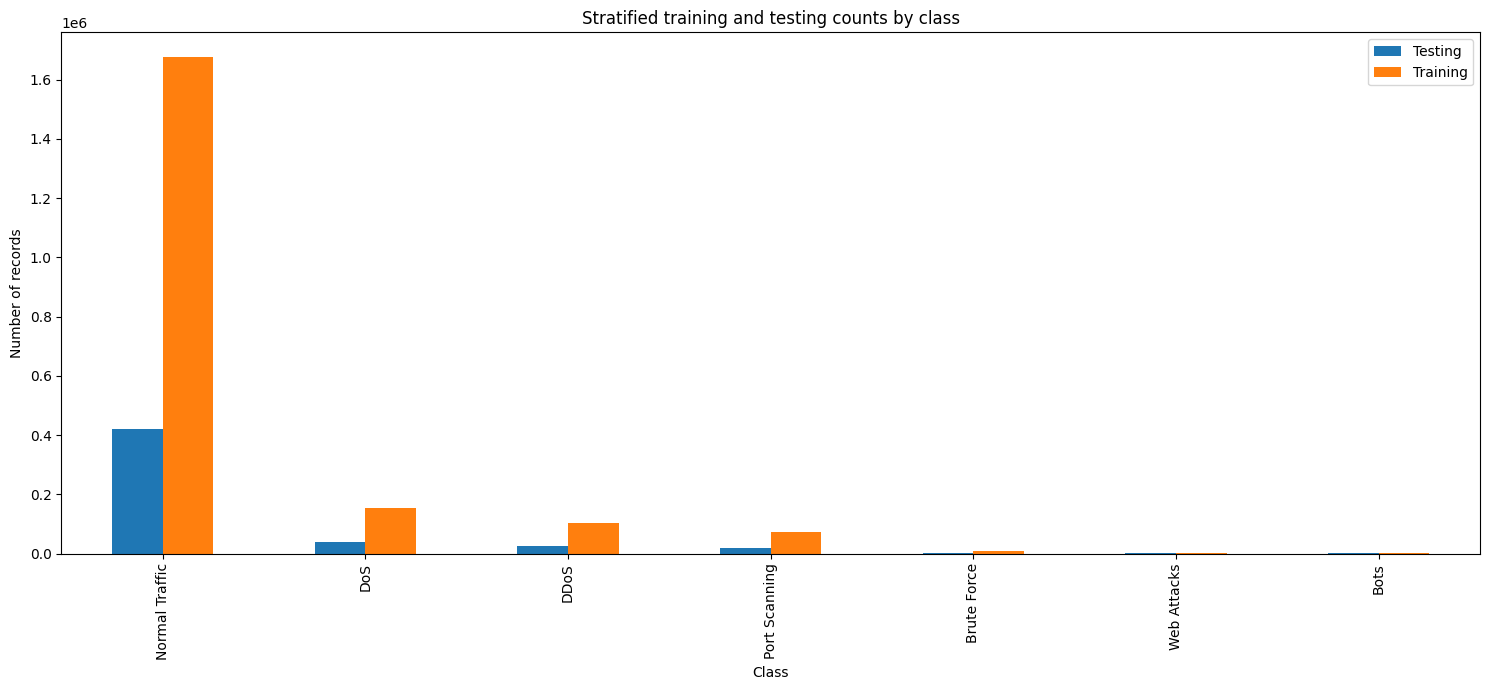

,split,percentage
0,Training,79.999921
1,Testing,20.000079


In [17]:
if not LOAD_SAVED_RESULTS_ONLY:
    split_class_pd = split_class_check.toPandas()

    split_long = split_class_pd.melt(
        id_vars=[TARGET_COL],
        value_vars=["training_count", "testing_count"],
        var_name="dataset_split",
        value_name="records"
    )

    split_pivot = (
        split_long
        .pivot(
            index=TARGET_COL,
            columns="dataset_split",
            values="records"
        )
        .fillna(0)
    )

    split_pivot = split_pivot.loc[
        split_pivot.sum(axis=1).sort_values(ascending=False).index
    ]

    split_pivot.plot(
        kind="bar",
        figsize=(15, 7)
    )

    plt.xlabel("Class")
    plt.ylabel("Number of records")
    plt.title("Stratified training and testing counts by class")
    plt.xticks(rotation=90)
    plt.legend(["Testing", "Training"])
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/06_stratified_split_by_class.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    split_percentages = pd.DataFrame({
        "split": ["Training", "Testing"],
        "percentage": [
            100.0 * train_count / max(train_count + test_count, 1),
            100.0 * test_count / max(train_count + test_count, 1)
        ]
    })

    display(split_percentages)
else:
    pass


In [18]:
if not LOAD_SAVED_RESULTS_ONLY:
    imputed_cols = [f"imputed_{i}" for i in range(len(feature_cols))]

    label_indexer = StringIndexer(
        inputCol=TARGET_COL,
        outputCol="label",
        handleInvalid="keep",
        stringOrderType="alphabetAsc"
    )

    imputer = Imputer(
        inputCols=feature_cols,
        outputCols=imputed_cols,
        strategy="median"
    )

    assembler = VectorAssembler(
        inputCols=imputed_cols,
        outputCol="features",
        handleInvalid="error"
    )

    preprocessing_pipeline = Pipeline(
        stages=[label_indexer, imputer, assembler]
    )

    preprocessing_model = preprocessing_pipeline.fit(train_raw)

    train_prepared = (
        preprocessing_model
        .transform(train_raw)
        .select(TARGET_COL, "label", "features")
        .cache()
    )

    test_prepared = (
        preprocessing_model
        .transform(test_raw)
        .select(TARGET_COL, "label", "features")
        .cache()
    )

    print("Prepared training rows:", train_prepared.count())
    print("Prepared testing rows:", test_prepared.count())

    label_indexer_model = preprocessing_model.stages[0]
    label_names = list(label_indexer_model.labels)
    number_of_labels = len(label_names)

    print("Class index mapping:")
    for index, name in enumerate(label_names):
        print(f"  {index} -> {name}")
else:
    pass


Prepared training rows: 2016470
Prepared testing rows: 504120
Class index mapping:
  0 -> Bots
  1 -> Brute Force
  2 -> DDoS
  3 -> DoS
  4 -> Normal Traffic
  5 -> Port Scanning
  6 -> Web Attacks


,numerical_label,original_class_name
0,0,Bots
1,1,Brute Force
2,2,DDoS
3,3,DoS
4,4,Normal Traffic
5,5,Port Scanning
6,6,Web Attacks


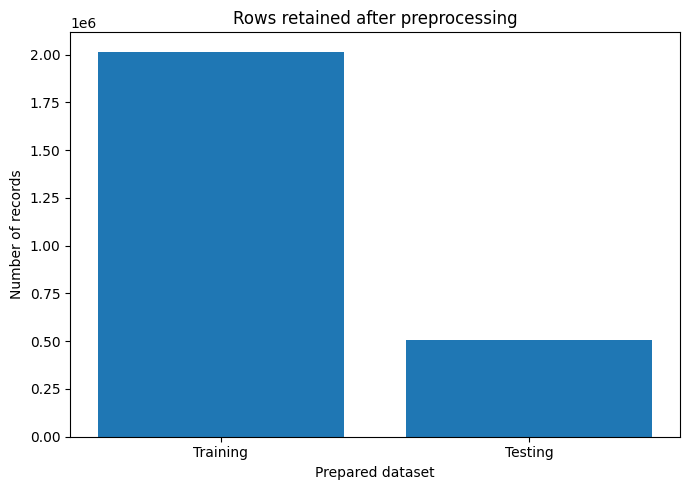

In [19]:
if not LOAD_SAVED_RESULTS_ONLY:
    label_mapping = pd.DataFrame({
        "numerical_label": list(range(number_of_labels)),
        "original_class_name": label_names
    })

    display(label_mapping)

    preprocessing_sizes = pd.DataFrame({
        "prepared_dataset": ["Training", "Testing"],
        "records": [
            train_prepared.count(),
            test_prepared.count()
        ]
    })

    plt.figure(figsize=(7, 5))
    plt.bar(
        preprocessing_sizes["prepared_dataset"],
        preprocessing_sizes["records"]
    )
    plt.xlabel("Prepared dataset")
    plt.ylabel("Number of records")
    plt.title("Rows retained after preprocessing")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/07_preprocessing_output_rows.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    label_mapping.to_csv(
        f"{RESULTS_OUTPUT_PATH}/label_index_mapping.csv",
        index=False
    )
else:
    pass


In [20]:
if not LOAD_SAVED_RESULTS_ONLY:
    training_class_counts = (
        train_prepared
        .groupBy("label")
        .count()
    )

    training_total = train_prepared.count()
    training_number_of_classes = training_class_counts.count()
    minimum_training_class_count = int(
        training_class_counts.agg(F.min("count")).first()[0]
    )

    EFFECTIVE_CV_FOLDS = min(
        CV_FOLDS,
        minimum_training_class_count
    )

    if EFFECTIVE_CV_FOLDS < 2:
        raise ValueError(
            "At least two training examples per class are required "
            "for cross-validation."
        )

    if EFFECTIVE_CV_FOLDS != CV_FOLDS:
        print(
            f"CV folds reduced from {CV_FOLDS} to {EFFECTIVE_CV_FOLDS} "
            "because of a rare class."
        )

    class_weights = (
        training_class_counts
        .withColumn(
            "classWeight",
            F.lit(float(training_total))
            / (
                F.lit(float(training_number_of_classes))
                * F.col("count")
            )
        )
        .select("label", "classWeight")
    )

    train_weighted = (
        train_prepared
        .join(class_weights, on="label", how="left")
        .repartition(64, "label")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    cv_rows_per_class = max(
        EFFECTIVE_CV_FOLDS,
        int(CV_MAX_ROWS // max(training_number_of_classes, 1))
    )

    cv_sample_window = (
        Window
        .partitionBy("label")
        .orderBy(F.rand(SEED))
    )

    cv_training = (
        train_weighted
        .withColumn(
            "_cv_sample_order",
            F.row_number().over(cv_sample_window)
        )
        .filter(F.col("_cv_sample_order") <= F.lit(cv_rows_per_class))
        .drop("_cv_sample_order")
    )

    cv_order_window = (
        Window
        .partitionBy("label")
        .orderBy(F.rand(SEED + 1))
    )

    cv_training = (
        cv_training
        .withColumn(
            "_cv_order",
            F.row_number().over(cv_order_window)
        )
        .withColumn(
            "_cv_fold",
            F.pmod(
                F.col("_cv_order") - F.lit(1),
                F.lit(EFFECTIVE_CV_FOLDS)
            ).cast("int")
        )
        .drop("_cv_order")
        .repartition(64, "_cv_fold")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    cv_training_count = cv_training.count()

    print("Calculated class weights:")
    class_weights.orderBy("label").show(100, truncate=False)

    print(f"Complete weighted training rows: {train_weighted.count():,}")
    print(f"Cross-validation tuning rows:    {cv_training_count:,}")
    print(f"Cross-validation folds:          {EFFECTIVE_CV_FOLDS}")
    print(f"Maximum rows retained per class: {cv_rows_per_class:,}")

    print("Class counts inside each cross-validation fold:")
    (
        cv_training
        .groupBy("_cv_fold", "label")
        .count()
        .orderBy("_cv_fold", "label")
        .show(500, truncate=False)
    )
else:
    pass


Calculated class weights:
+-----+-------------------+
|label|classWeight        |
+-----+-------------------+
|0.0  |184.89547038327527 |
|1.0  |39.35343481654957  |
|2.0  |2.8128535299639967 |
|3.0  |1.8585456583211364 |
|4.0  |0.17188638503191261|
|5.0  |3.970327928566506  |
|6.0  |168.06717786297716 |
+-----+-------------------+

Complete weighted training rows: 2,016,470
Cross-validation tuning rows:    53,448
Cross-validation folds:          3
Maximum rows retained per class: 10,714
Class counts inside each cross-validation fold:
+--------+-----+-----+
|_cv_fold|label|count|
+--------+-----+-----+
|0       |0.0  |520  |
|0       |1.0  |2440 |
|0       |2.0  |3572 |
|0       |3.0  |3572 |
|0       |4.0  |3572 |
|0       |5.0  |3572 |
|0       |6.0  |572  |
|1       |0.0  |519  |
|1       |1.0  |2440 |
|1       |2.0  |3571 |
|1       |3.0  |3571 |
|1       |4.0  |3571 |
|1       |5.0  |3571 |
|1       |6.0  |571  |
|2       |0.0  |519  |
|2       |1.0  |2440 |
|2       |2.0  |3571 |

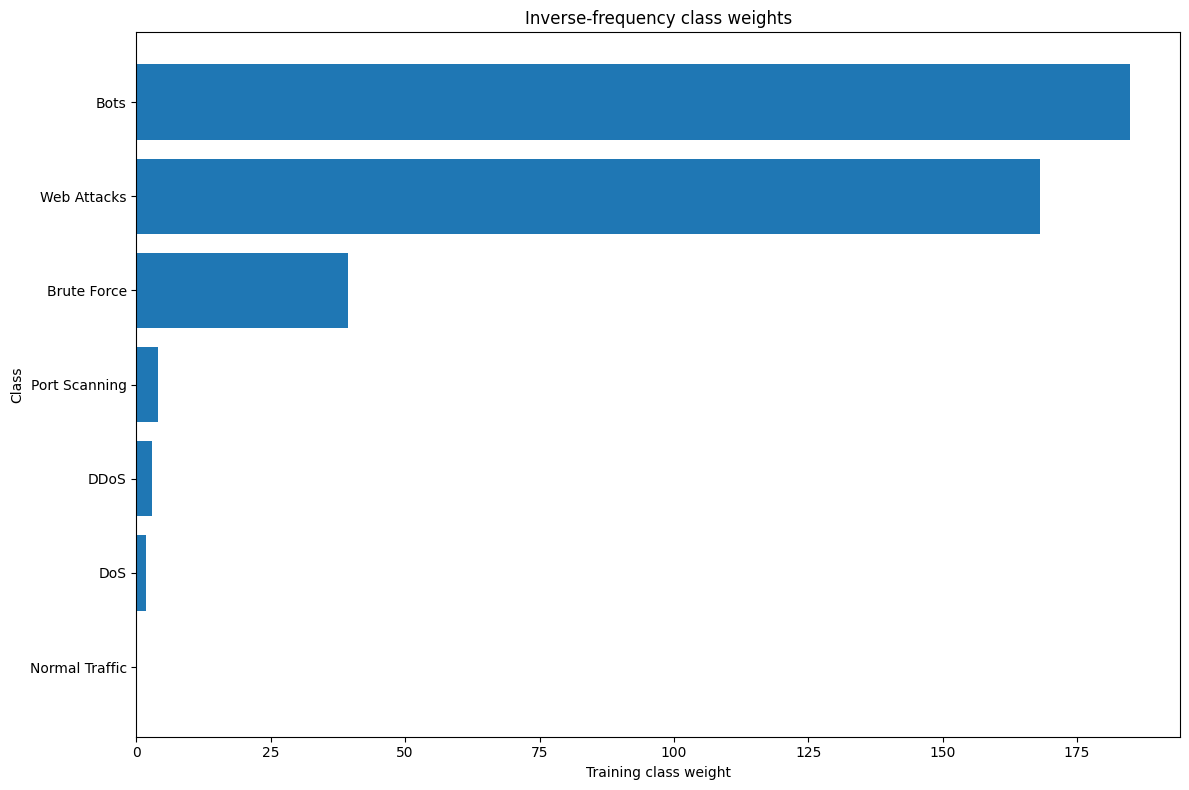

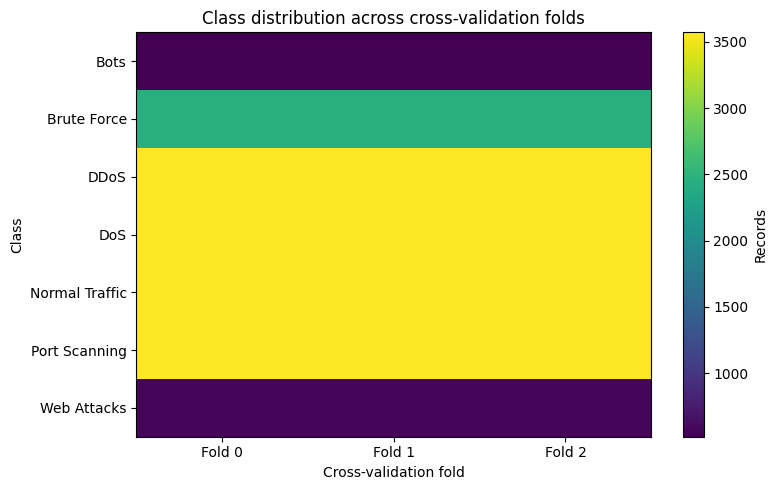

In [21]:
if not LOAD_SAVED_RESULTS_ONLY:
    class_weights_pd = class_weights.toPandas()
    class_weights_pd["class"] = (
        class_weights_pd["label"]
        .astype(int)
        .map(dict(enumerate(label_names)))
    )

    class_weights_pd = class_weights_pd.sort_values(
        "classWeight",
        ascending=True
    )

    plt.figure(figsize=(12, 8))
    plt.barh(
        class_weights_pd["class"],
        class_weights_pd["classWeight"]
    )
    plt.xlabel("Training class weight")
    plt.ylabel("Class")
    plt.title("Inverse-frequency class weights")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/08_class_weights.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    fold_distribution_pd = (
        cv_training
        .groupBy("_cv_fold", "label")
        .count()
        .toPandas()
    )

    fold_distribution_pd["class"] = (
        fold_distribution_pd["label"]
        .astype(int)
        .map(dict(enumerate(label_names)))
    )

    fold_heatmap = (
        fold_distribution_pd
        .pivot_table(
            index="class",
            columns="_cv_fold",
            values="count",
            aggfunc="sum",
            fill_value=0
        )
    )

    plt.figure(figsize=(8, max(5, 0.42 * len(fold_heatmap))))
    plt.imshow(fold_heatmap.to_numpy(), aspect="auto")
    plt.colorbar(label="Records")
    plt.xticks(
        range(len(fold_heatmap.columns)),
        [f"Fold {int(value)}" for value in fold_heatmap.columns]
    )
    plt.yticks(
        range(len(fold_heatmap.index)),
        fold_heatmap.index
    )
    plt.xlabel("Cross-validation fold")
    plt.ylabel("Class")
    plt.title("Class distribution across cross-validation folds")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/08_cross_validation_fold_heatmap.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


In [22]:
if not LOAD_SAVED_RESULTS_ONLY:
    def spark_overall_metrics(predictions):
        metric_names = {
            "accuracy": "accuracy",
            "weighted_precision": "weightedPrecision",
            "weighted_recall": "weightedRecall",
            "weighted_f1": "f1"
        }

        results = {}
        for output_name, spark_metric in metric_names.items():
            evaluator = MulticlassClassificationEvaluator(
                labelCol="label",
                predictionCol="prediction",
                metricName=spark_metric
            )
            results[output_name] = float(evaluator.evaluate(predictions))

        return results


    def aggregated_confusion_matrix(predictions, label_names):
        labels = list(range(len(label_names)))

        aggregated = (
            predictions
            .groupBy("label", "prediction")
            .count()
            .toPandas()
        )

        matrix = pd.DataFrame(
            0,
            index=labels,
            columns=labels,
            dtype=np.int64
        )

        for row in aggregated.itertuples(index=False):
            actual = int(row.label)
            predicted = int(row.prediction)

            if actual in matrix.index and predicted in matrix.columns:
                matrix.loc[actual, predicted] += int(row.count)

        matrix.index = label_names
        matrix.columns = label_names
        return matrix


    def per_class_metrics_from_matrix(matrix):
        values = matrix.to_numpy(dtype=float)
        total = values.sum()

        support = values.sum(axis=1)
        predicted_total = values.sum(axis=0)
        true_positive = np.diag(values)

        precision = np.divide(
            true_positive,
            predicted_total,
            out=np.zeros_like(true_positive),
            where=predicted_total != 0
        )

        recall = np.divide(
            true_positive,
            support,
            out=np.zeros_like(true_positive),
            where=support != 0
        )

        f1 = np.divide(
            2 * precision * recall,
            precision + recall,
            out=np.zeros_like(precision),
            where=(precision + recall) != 0
        )

        accuracy = true_positive.sum() / total if total else 0.0

        table = pd.DataFrame({
            "class": matrix.index,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support.astype(int)
        })

        summary = {
            "accuracy_from_matrix": float(accuracy),
            "macro_precision": float(np.mean(precision)),
            "macro_recall": float(np.mean(recall)),
            "macro_f1": float(np.mean(f1)),
            "weighted_precision_from_matrix": float(
                np.average(precision, weights=support)
            ),
            "weighted_recall_from_matrix": float(
                np.average(recall, weights=support)
            ),
            "weighted_f1_from_matrix": float(
                np.average(f1, weights=support)
            )
        }

        return table, summary


    def complete_evaluation(predictions, model_name, label_names):
        overall = spark_overall_metrics(predictions)
        matrix = aggregated_confusion_matrix(predictions, label_names)
        per_class, matrix_summary = per_class_metrics_from_matrix(matrix)

        summary = {
            "model": model_name,
            **overall,
            **matrix_summary
        }

        return summary, per_class, matrix
else:
    pass


In [23]:
if not LOAD_SAVED_RESULTS_ONLY:
    decision_tree = DecisionTreeClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        maxDepth=10,
        minInstancesPerNode=2,
        seed=SEED
    )

    start_time = time.time()
    decision_tree_model = decision_tree.fit(train_prepared)
    decision_tree_training_seconds = time.time() - start_time

    decision_tree_predictions = decision_tree_model.transform(test_prepared)

    dt_summary, dt_per_class, dt_matrix = complete_evaluation(
        decision_tree_predictions,
        "Decision Tree baseline",
        label_names
    )

    dt_summary["training_seconds"] = decision_tree_training_seconds

    display(pd.DataFrame([dt_summary]))
    display(dt_per_class.sort_values("f1"))

    print(f"Decision Tree training time: {decision_tree_training_seconds:.2f} seconds")
else:
    pass


,model,accuracy,weighted_precision,weighted_recall,weighted_f1,accuracy_from_matrix,macro_precision,macro_recall,macro_f1,weighted_precision_from_matrix,weighted_recall_from_matrix,weighted_f1_from_matrix,training_seconds
0,Decision Tree baseline,0.996251,0.995527,0.996251,0.995874,0.996251,0.814949,0.82806,0.820641,0.995527,0.996251,0.995874,66.048465


,class,precision,recall,f1,support
0,Bots,0.000000,0.000000,0.000000,390
6,Web Attacks,0.722986,0.857809,0.784648,429
1,Brute Force,0.998876,0.971585,0.985042,1830
3,DoS,0.997736,0.977935,0.987736,38749
5,Port Scanning,0.988576,0.992337,0.990453,18139
4,Normal Traffic,0.996546,0.999212,0.997877,418980
2,DDoS,0.999922,0.997539,0.998729,25603


Decision Tree training time: 66.05 seconds


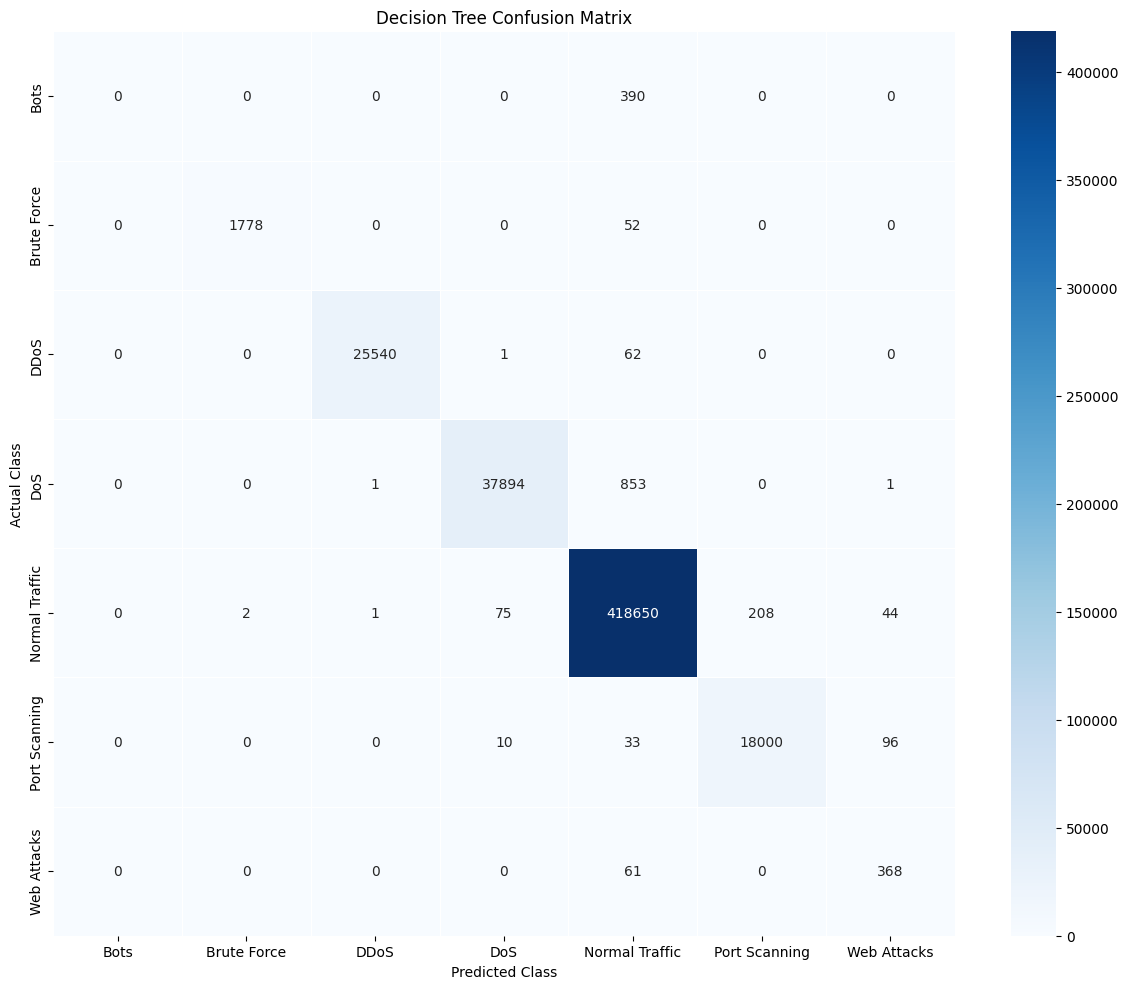

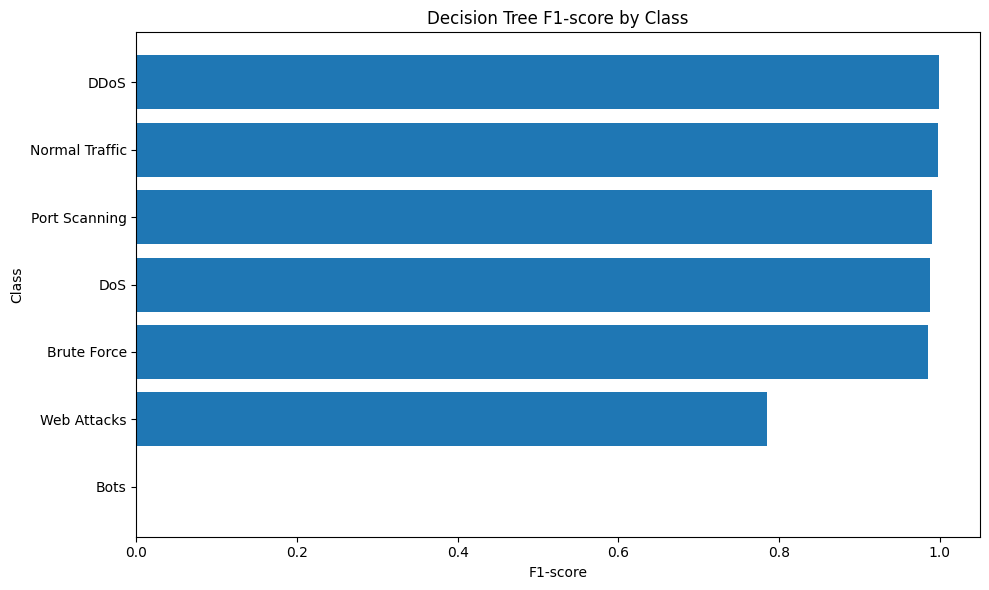

In [24]:
if not LOAD_SAVED_RESULTS_ONLY:
    import seaborn as sns

    # ---------------------------------------------------------------
    # Decision Tree Confusion Matrix
    # ---------------------------------------------------------------
    plt.figure(figsize=(12, 10))

    sns.heatmap(
        dt_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="white"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("Decision Tree Confusion Matrix")

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/09_decision_tree_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ---------------------------------------------------------------
    # Decision Tree F1-score by Class
    # ---------------------------------------------------------------
    dt_f1_view = dt_per_class.sort_values("f1", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        dt_f1_view["class"],
        dt_f1_view["f1"]
    )

    plt.xlim(0, 1.05)
    plt.xlabel("F1-score")
    plt.ylabel("Class")
    plt.title("Decision Tree F1-score by Class")

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/09_decision_tree_f1_by_class.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    pass

In [25]:
if not LOAD_SAVED_RESULTS_ONLY:
    rf_evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    )

    rf_accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    )

    # Curated configurations tune five important Random Forest settings while
    # keeping the total number of fits safe for a standard Colab runtime.
    RF_CANDIDATE_CONFIGS = [
        {
            "candidate_id": "RF_A",
            "numTrees": 25,
            "maxDepth": 8,
            "minInstancesPerNode": 1,
            "subsamplingRate": 0.80,
            "maxBins": 32
        },
        {
            "candidate_id": "RF_B",
            "numTrees": 40,
            "maxDepth": 10,
            "minInstancesPerNode": 1,
            "subsamplingRate": 0.80,
            "maxBins": 32
        },
        {
            "candidate_id": "RF_C",
            "numTrees": 40,
            "maxDepth": 12,
            "minInstancesPerNode": 2,
            "subsamplingRate": 0.80,
            "maxBins": 64
        },
        {
            "candidate_id": "RF_D",
            "numTrees": 60,
            "maxDepth": 12,
            "minInstancesPerNode": 5,
            "subsamplingRate": 1.00,
            "maxBins": 64
        }
    ]

    candidate_configuration_table = pd.DataFrame(RF_CANDIDATE_CONFIGS)
    display(candidate_configuration_table)

    print("Candidate configurations:", len(RF_CANDIDATE_CONFIGS))
    print(
        "Total sequential cross-validation fits:",
        len(RF_CANDIDATE_CONFIGS) * EFFECTIVE_CV_FOLDS
    )
else:
    pass


,candidate_id,numTrees,maxDepth,minInstancesPerNode,subsamplingRate,maxBins
0,RF_A,25,8,1,0.8,32
1,RF_B,40,10,1,0.8,32
2,RF_C,40,12,2,0.8,64
3,RF_D,60,12,5,1.0,64


Candidate configurations: 4
Total sequential cross-validation fits: 12


In [26]:
if not LOAD_SAVED_RESULTS_ONLY:
    cv_fold_rows = []
    cross_validation_start = time.time()

    for candidate_config in RF_CANDIDATE_CONFIGS:
        candidate_id = candidate_config["candidate_id"]

        for fold_index in range(EFFECTIVE_CV_FOLDS):
            print(
                f"Training {candidate_id}, "
                f"fold {fold_index + 1}/{EFFECTIVE_CV_FOLDS}..."
            )

            fold_training = (
                cv_training
                .filter(F.col("_cv_fold") != fold_index)
                .drop("_cv_fold")
            )

            fold_validation = (
                cv_training
                .filter(F.col("_cv_fold") == fold_index)
                .drop("_cv_fold")
            )

            fold_model_definition = RandomForestClassifier(
                featuresCol="features",
                labelCol="label",
                predictionCol="prediction",
                weightCol="classWeight",
                seed=SEED + fold_index,
                featureSubsetStrategy="sqrt",
                numTrees=int(candidate_config["numTrees"]),
                maxDepth=int(candidate_config["maxDepth"]),
                minInstancesPerNode=int(
                    candidate_config["minInstancesPerNode"]
                ),
                subsamplingRate=float(
                    candidate_config["subsamplingRate"]
                ),
                maxBins=int(candidate_config["maxBins"])
            )

            fold_start = time.time()
            fold_model = fold_model_definition.fit(fold_training)
            fold_predictions = fold_model.transform(
                fold_validation
            ).select("label", "prediction")
            fold_seconds = time.time() - fold_start

            fold_weighted_f1 = rf_evaluator.evaluate(fold_predictions)
            fold_accuracy = rf_accuracy_evaluator.evaluate(fold_predictions)

            cv_fold_rows.append({
                **candidate_config,
                "fold": int(fold_index),
                "validation_weighted_f1": float(fold_weighted_f1),
                "validation_accuracy": float(fold_accuracy),
                "fit_and_validation_seconds": float(fold_seconds)
            })

            print(
                f"  weighted F1={fold_weighted_f1:.5f}, "
                f"accuracy={fold_accuracy:.5f}, "
                f"time={fold_seconds:.1f}s"
            )

            del fold_model, fold_predictions
            gc.collect()

    cross_validation_seconds = time.time() - cross_validation_start

    cv_fold_results = pd.DataFrame(cv_fold_rows)

    group_columns = [
        "candidate_id",
        "numTrees",
        "maxDepth",
        "minInstancesPerNode",
        "subsamplingRate",
        "maxBins"
    ]

    tuning_results = (
        cv_fold_results
        .groupby(group_columns, as_index=False)
        .agg(
            mean_validation_weighted_f1=(
                "validation_weighted_f1",
                "mean"
            ),
            std_validation_weighted_f1=(
                "validation_weighted_f1",
                "std"
            ),
            mean_validation_accuracy=(
                "validation_accuracy",
                "mean"
            ),
            std_validation_accuracy=(
                "validation_accuracy",
                "std"
            ),
            mean_fold_seconds=(
                "fit_and_validation_seconds",
                "mean"
            )
        )
        .fillna(0.0)
        .sort_values(
            [
                "mean_validation_weighted_f1",
                "std_validation_weighted_f1",
                "mean_validation_accuracy"
            ],
            ascending=[False, True, False]
        )
        .reset_index(drop=True)
    )

    best_configuration = tuning_results.iloc[0]

    BEST_NUM_TREES = int(best_configuration["numTrees"])
    BEST_MAX_DEPTH = int(best_configuration["maxDepth"])
    BEST_MIN_INSTANCES = int(
        best_configuration["minInstancesPerNode"]
    )
    BEST_SUBSAMPLING_RATE = float(
        best_configuration["subsamplingRate"]
    )
    BEST_MAX_BINS = int(best_configuration["maxBins"])

    print(f"Cross-validation time: {cross_validation_seconds:.2f} seconds")
    print("Best candidate:", best_configuration["candidate_id"])
    print("Best number of trees:", BEST_NUM_TREES)
    print("Best maximum depth:", BEST_MAX_DEPTH)
    print("Best minimum node instances:", BEST_MIN_INSTANCES)
    print("Best subsampling rate:", BEST_SUBSAMPLING_RATE)
    print("Best maximum bins:", BEST_MAX_BINS)

    # Coursework-required mean and standard deviation. These values come
    # from the validation folds of the selected hyperparameter candidate.
    cv_mean_std_table = pd.DataFrame({
        "metric": [
            "cross_validation_accuracy",
            "cross_validation_weighted_f1"
        ],
        "mean": [
            float(best_configuration["mean_validation_accuracy"]),
            float(best_configuration["mean_validation_weighted_f1"])
        ],
        "standard_deviation": [
            float(best_configuration["std_validation_accuracy"]),
            float(best_configuration["std_validation_weighted_f1"])
        ]
    })

    cv_mean_std_table["report_format"] = cv_mean_std_table.apply(
        lambda row: (
            f"{row['mean']:.4f} ± "
            f"{row['standard_deviation']:.4f}"
        ),
        axis=1
    )

    print("\nCoursework mean ± standard deviation:")
    display(cv_mean_std_table)


    final_random_forest = RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        predictionCol="prediction",
        weightCol="classWeight",
        seed=SEED,
        featureSubsetStrategy="sqrt",
        numTrees=BEST_NUM_TREES,
        maxDepth=BEST_MAX_DEPTH,
        minInstancesPerNode=BEST_MIN_INSTANCES,
        subsamplingRate=BEST_SUBSAMPLING_RATE,
        maxBins=BEST_MAX_BINS
    )

    print("Fitting the selected Random Forest on the complete training set...")
    final_training_start = time.time()
    best_random_forest = final_random_forest.fit(train_weighted)
    final_random_forest_training_seconds = (
        time.time() - final_training_start
    )

    print(
        "Final complete-training fit time: "
        f"{final_random_forest_training_seconds:.2f} seconds"
    )
else:
    pass


Training RF_A, fold 1/3...
  weighted F1=0.98358, accuracy=0.98316, time=34.7s
Training RF_A, fold 2/3...
  weighted F1=0.98157, accuracy=0.98103, time=30.4s
Training RF_A, fold 3/3...
  weighted F1=0.98003, accuracy=0.97929, time=30.7s
Training RF_B, fold 1/3...
  weighted F1=0.99076, accuracy=0.99063, time=53.3s
Training RF_B, fold 2/3...
  weighted F1=0.99131, accuracy=0.99107, time=51.4s
Training RF_B, fold 3/3...
  weighted F1=0.99235, accuracy=0.99225, time=60.4s
Training RF_C, fold 1/3...
  weighted F1=0.99344, accuracy=0.99338, time=85.6s
Training RF_C, fold 2/3...
  weighted F1=0.99417, accuracy=0.99411, time=103.4s
Training RF_C, fold 3/3...
  weighted F1=0.99367, accuracy=0.99360, time=100.0s
Training RF_D, fold 1/3...
  weighted F1=0.99287, accuracy=0.99282, time=150.0s
Training RF_D, fold 2/3...
  weighted F1=0.99395, accuracy=0.99388, time=127.0s
Training RF_D, fold 3/3...
  weighted F1=0.99350, accuracy=0.99343, time=122.8s
Cross-validation time: 1009.34 seconds
Best can

,metric,mean,standard_deviation,report_format
0,cross_validation_accuracy,0.993695,0.000373,0.9937 ± 0.0004
1,cross_validation_weighted_f1,0.993758,0.000374,0.9938 ± 0.0004


Fitting the selected Random Forest on the complete training set...
Final complete-training fit time: 589.58 seconds


In [27]:
if not LOAD_SAVED_RESULTS_ONLY:
    print("Per-fold cross-validation results:")
    display(cv_fold_results)

    print("Aggregated hyperparameter tuning results:")
    display(tuning_results)

    cv_fold_results.to_csv(
        f"{RESULTS_OUTPUT_PATH}/random_forest_cv_fold_results.csv",
        index=False
    )

    tuning_results.to_csv(
        f"{RESULTS_OUTPUT_PATH}/random_forest_tuning_results.csv",
        index=False
    )
else:
    pass


Per-fold cross-validation results:


,candidate_id,numTrees,maxDepth,minInstancesPerNode,subsamplingRate,maxBins,fold,validation_weighted_f1,validation_accuracy,fit_and_validation_seconds
0,RF_A,25,8,1,0.8,32,0,0.983579,0.983165,34.683226
1,RF_A,25,8,1,0.8,32,1,0.981573,0.981026,30.434369
2,RF_A,25,8,1,0.8,32,2,0.980032,0.979286,30.661116
3,RF_B,40,10,1,0.8,32,0,0.990759,0.990629,53.313291
4,RF_B,40,10,1,0.8,32,1,0.991310,0.991074,51.423763
5,RF_B,40,10,1,0.8,32,2,0.992350,0.992253,60.398627
6,RF_C,40,12,2,0.8,64,0,0.993436,0.993378,85.621566
7,RF_C,40,12,2,0.8,64,1,0.994168,0.994106,103.379290
8,RF_C,40,12,2,0.8,64,2,0.993669,0.993601,99.962807
9,RF_D,60,12,5,1.0,64,0,0.992875,0.992817,150.041008


Aggregated hyperparameter tuning results:


,candidate_id,numTrees,maxDepth,minInstancesPerNode,subsamplingRate,maxBins,mean_validation_weighted_f1,std_validation_weighted_f1,mean_validation_accuracy,std_validation_accuracy,mean_fold_seconds
0,RF_C,40,12,2,0.8,64,0.993758,0.000374,0.993695,0.000373,96.321221
1,RF_D,60,12,5,1.0,64,0.993444,0.000542,0.993377,0.000534,133.273213
2,RF_B,40,10,1,0.8,32,0.991473,0.000808,0.991319,0.000839,55.045227
3,RF_A,25,8,1,0.8,32,0.981728,0.001779,0.981159,0.001943,31.926237


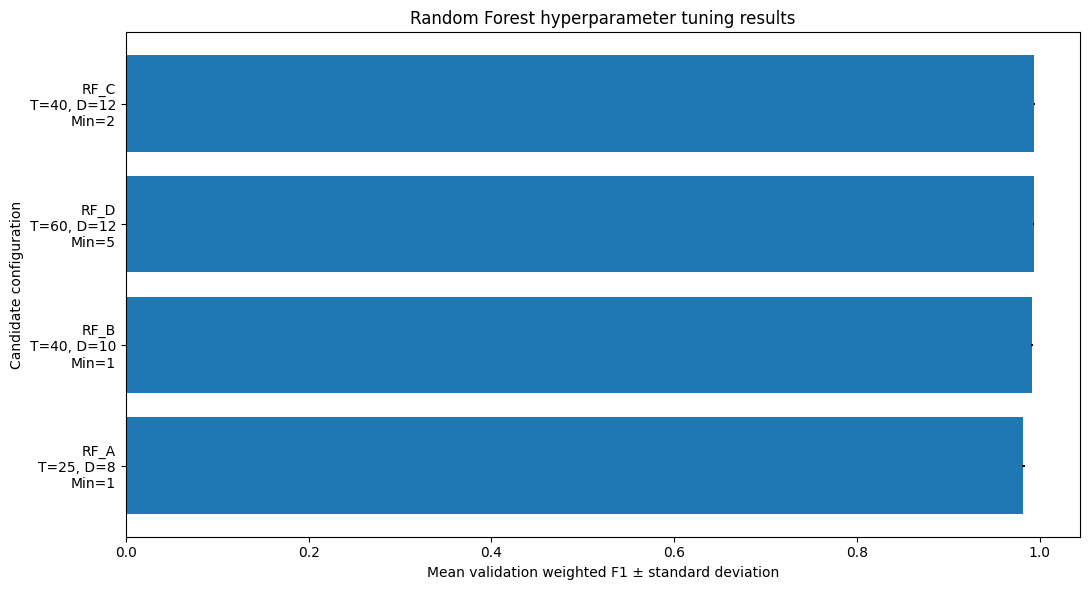

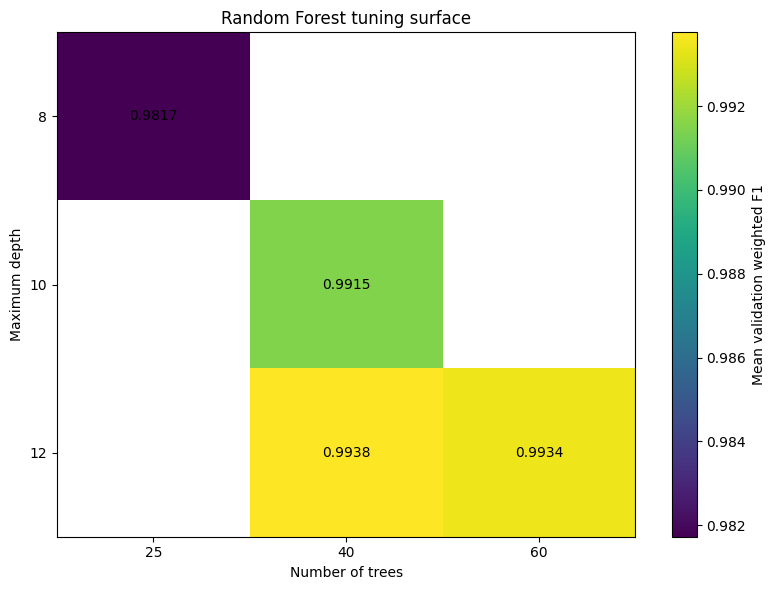

In [28]:
if not LOAD_SAVED_RESULTS_ONLY:
    tuning_plot = tuning_results.copy()
    tuning_plot["configuration"] = (
        tuning_plot["candidate_id"]
        + "\nT=" + tuning_plot["numTrees"].astype(int).astype(str)
        + ", D=" + tuning_plot["maxDepth"].astype(int).astype(str)
        + "\nMin=" + tuning_plot[
            "minInstancesPerNode"
        ].astype(int).astype(str)
    )

    tuning_plot = tuning_plot.sort_values(
        "mean_validation_weighted_f1",
        ascending=True
    )

    figure, axis = plt.subplots(figsize=(11, 6))
    axis.barh(
        tuning_plot["configuration"],
        tuning_plot["mean_validation_weighted_f1"],
        xerr=tuning_plot["std_validation_weighted_f1"]
    )
    axis.set_xlabel("Mean validation weighted F1 ± standard deviation")
    axis.set_ylabel("Candidate configuration")
    axis.set_title("Random Forest hyperparameter tuning results")
    figure.tight_layout()
    figure.savefig(
        f"{FIGURES_DIR}/10_random_forest_tuning_candidates.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)

    # A depth-versus-trees heatmap remains useful for the two most influential
    # structural hyperparameters.
    tuning_heatmap = tuning_results.pivot_table(
        index="maxDepth",
        columns="numTrees",
        values="mean_validation_weighted_f1",
        aggfunc="max"
    ).sort_index()

    figure, axis = plt.subplots(figsize=(8, 6))
    image = axis.imshow(
        tuning_heatmap.to_numpy(),
        aspect="auto"
    )
    figure.colorbar(
        image,
        ax=axis,
        label="Mean validation weighted F1"
    )
    axis.set_xticks(range(len(tuning_heatmap.columns)))
    axis.set_xticklabels(tuning_heatmap.columns)
    axis.set_yticks(range(len(tuning_heatmap.index)))
    axis.set_yticklabels(tuning_heatmap.index)
    axis.set_xlabel("Number of trees")
    axis.set_ylabel("Maximum depth")
    axis.set_title("Random Forest tuning surface")

    for row_index in range(tuning_heatmap.shape[0]):
        for column_index in range(tuning_heatmap.shape[1]):
            value = tuning_heatmap.iloc[row_index, column_index]
            if pd.notna(value):
                axis.text(
                    column_index,
                    row_index,
                    f"{value:.4f}",
                    ha="center",
                    va="center"
                )

    figure.tight_layout()
    figure.savefig(
        f"{FIGURES_DIR}/10_cross_validation_tuning_heatmap.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)
else:
    pass


In [29]:
if not LOAD_SAVED_RESULTS_ONLY:
    start_time = time.time()
    rf_predictions = (
        best_random_forest
        .transform(test_prepared)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    rf_predictions.count()
    rf_prediction_seconds = time.time() - start_time

    rf_summary, rf_per_class, rf_matrix = complete_evaluation(
        rf_predictions,
        "Weighted Random Forest",
        label_names
    )

    rf_summary["cross_validation_seconds"] = cross_validation_seconds
    rf_summary["final_training_seconds"] = final_random_forest_training_seconds
    rf_summary["prediction_seconds"] = rf_prediction_seconds
    rf_summary["best_num_trees"] = BEST_NUM_TREES
    rf_summary["best_max_depth"] = BEST_MAX_DEPTH
    rf_summary["best_min_instances_per_node"] = BEST_MIN_INSTANCES
    rf_summary["best_subsampling_rate"] = BEST_SUBSAMPLING_RATE
    rf_summary["best_max_bins"] = BEST_MAX_BINS

    model_comparison = pd.DataFrame([
        dt_summary,
        rf_summary
    ])

    display(model_comparison)
    display(rf_per_class.sort_values("f1"))

    model_comparison.to_csv(
        f"{RESULTS_OUTPUT_PATH}/model_comparison.csv",
        index=False
    )

    rf_per_class.to_csv(
        f"{RESULTS_OUTPUT_PATH}/random_forest_per_class_metrics.csv",
        index=False
    )
else:
    pass


,model,accuracy,weighted_precision,weighted_recall,weighted_f1,accuracy_from_matrix,macro_precision,macro_recall,macro_f1,weighted_precision_from_matrix,...,weighted_f1_from_matrix,training_seconds,cross_validation_seconds,final_training_seconds,prediction_seconds,best_num_trees,best_max_depth,best_min_instances_per_node,best_subsampling_rate,best_max_bins
0,Decision Tree baseline,0.996251,0.995527,0.996251,0.995874,0.996251,0.814949,0.828060,0.820641,0.995527,...,0.995874,66.048465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Weighted Random Forest,0.985206,0.997088,0.985206,0.990599,0.985206,0.761644,0.996032,0.792866,0.997088,...,0.990599,NaN,1009.342026,589.580606,23.622277,40.0,12.0,2.0,0.8,64.0


,class,precision,recall,f1,support
0,Bots,0.064790,0.997436,0.121677,390
6,Web Attacks,0.291866,0.995338,0.451374,429
4,Normal Traffic,0.999852,0.982412,0.991055,418980
3,DoS,0.986262,0.998632,0.992409,38749
5,Port Scanning,0.988813,0.998953,0.993857,18139
2,DDoS,0.999922,0.999453,0.999687,25603
1,Brute Force,1.000000,1.000000,1.000000,1830


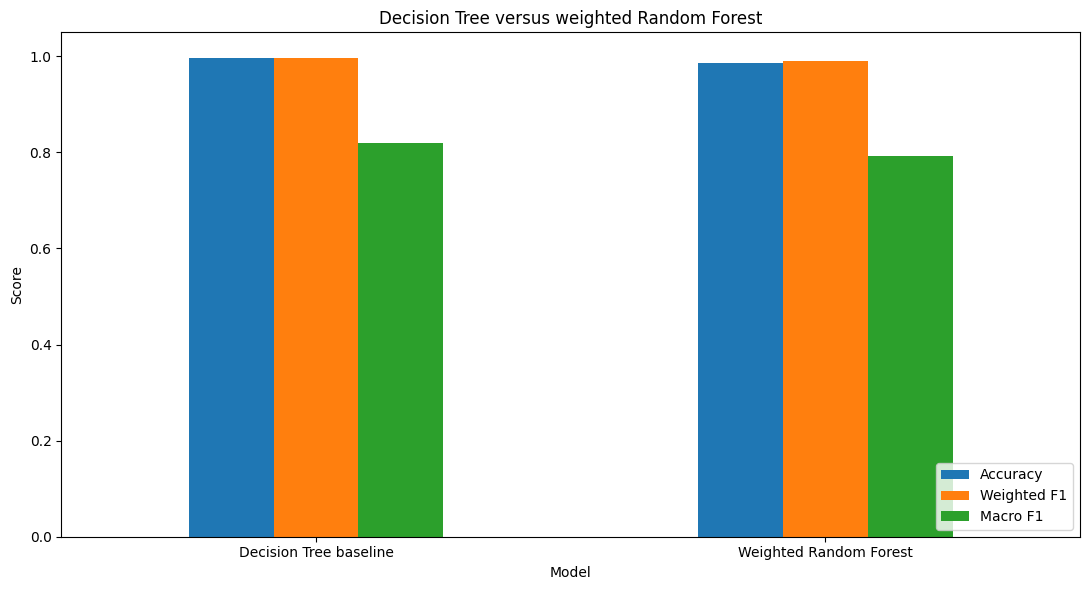

In [30]:
if not LOAD_SAVED_RESULTS_ONLY:
    comparison_metrics = (
        model_comparison
        .set_index("model")[
            ["accuracy", "weighted_f1", "macro_f1"]
        ]
    )

    comparison_metrics.plot(
        kind="bar",
        figsize=(11, 6)
    )

    plt.ylim(0, 1.05)
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.title("Decision Tree versus weighted Random Forest")
    plt.xticks(rotation=0)
    plt.legend(
        ["Accuracy", "Weighted F1", "Macro F1"],
        loc="lower right"
    )
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/11_model_metric_comparison.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

else:
    pass


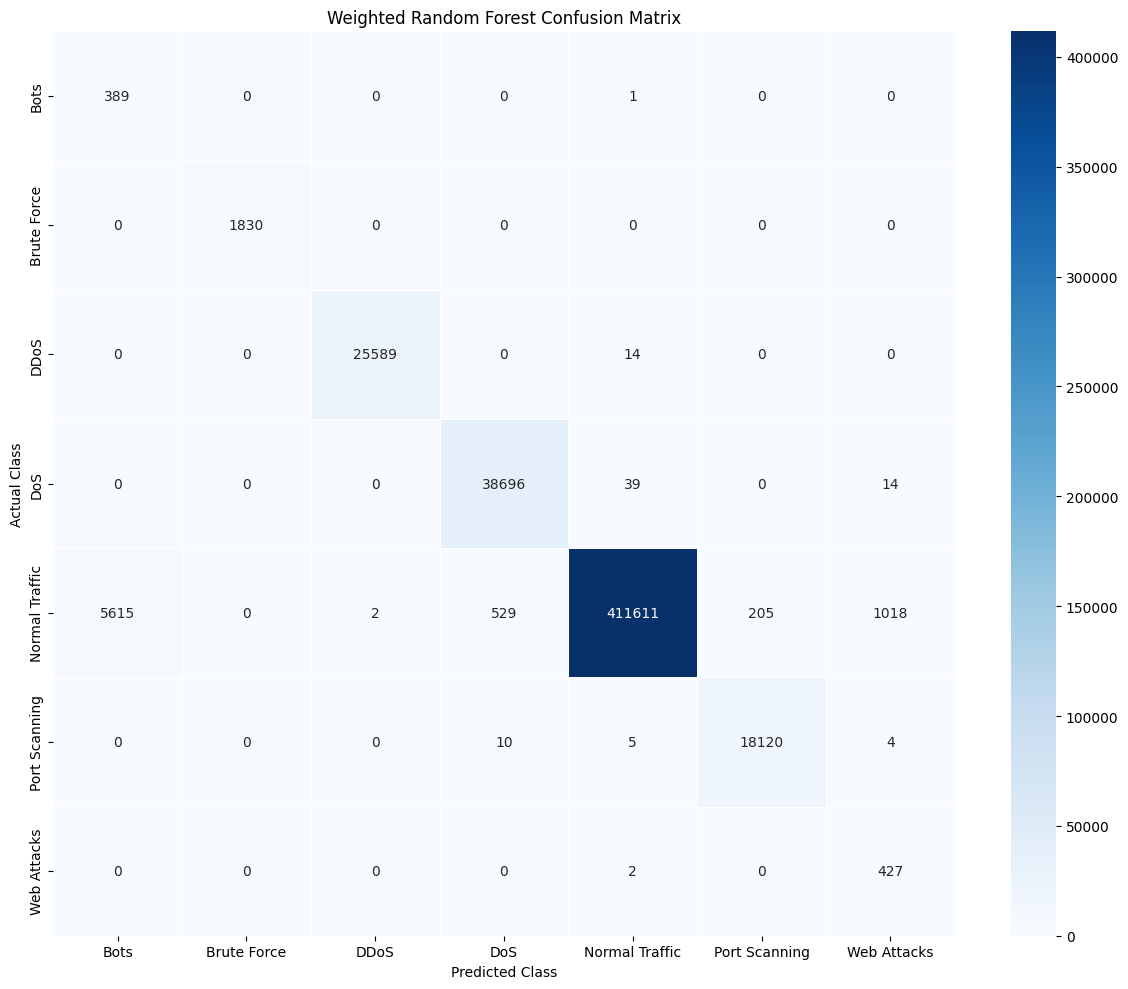

In [31]:
if not LOAD_SAVED_RESULTS_ONLY:
    # ---------------------------------------------------------------
    # Weighted Random Forest Confusion Matrix
    # ---------------------------------------------------------------
    plt.figure(figsize=(12, 10))

    sns.heatmap(
        rf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=rf_matrix.to_numpy().max(),
        cbar=True,
        linewidths=0.5,
        linecolor="white"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("Weighted Random Forest Confusion Matrix")

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/random_forest_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save confusion matrix as CSV
    rf_matrix.to_csv(
        f"{RESULTS_OUTPUT_PATH}/random_forest_confusion_matrix.csv"
    )

else:
    pass

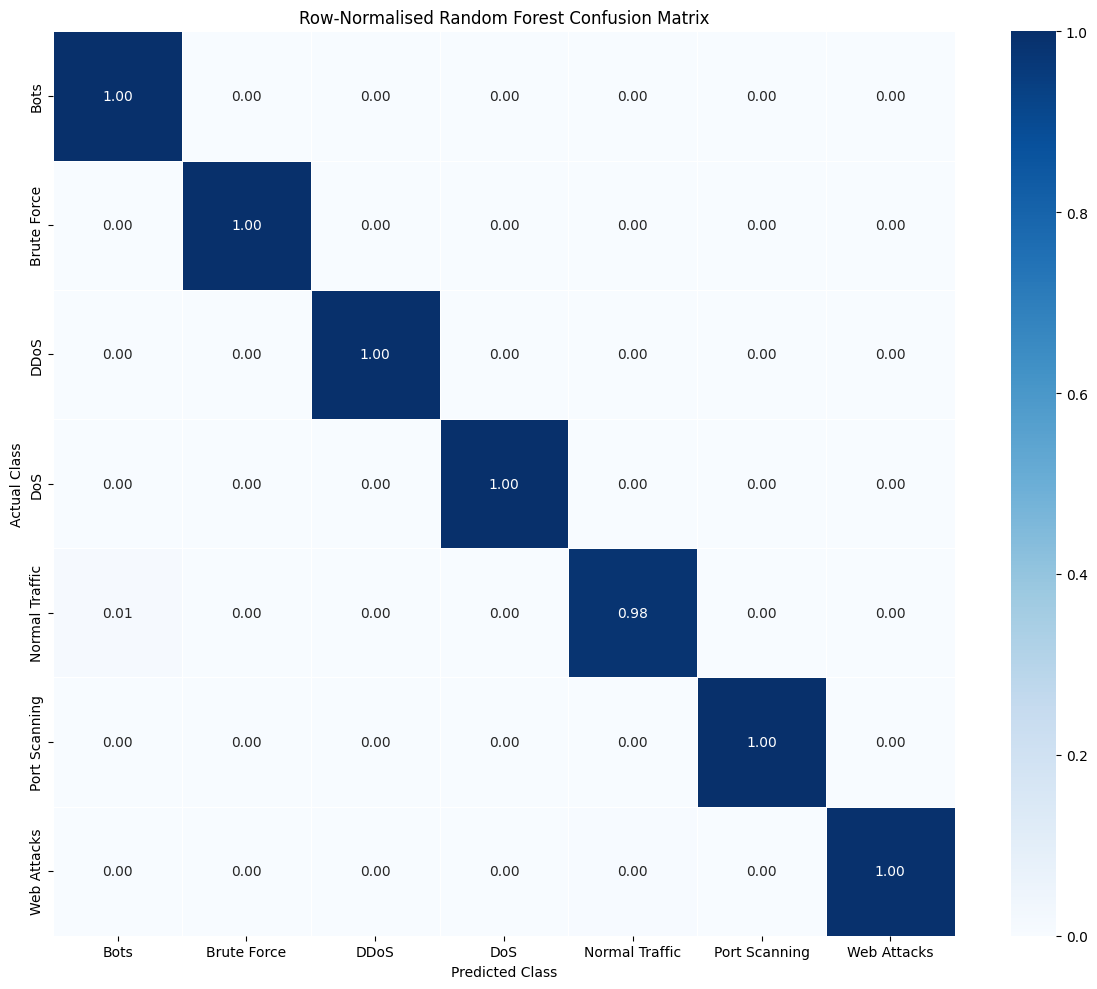

In [32]:
if not LOAD_SAVED_RESULTS_ONLY:
    # ---------------------------------------------------------------
    # Row-normalised Random Forest Confusion Matrix
    # ---------------------------------------------------------------
    rf_row_totals = rf_matrix.sum(axis=1).replace(0, np.nan)

    rf_matrix_normalised = (
        rf_matrix
        .div(rf_row_totals, axis=0)
        .fillna(0)
    )

    plt.figure(figsize=(12, 10))

    sns.heatmap(
        rf_matrix_normalised,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.5,
        linecolor="white"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title("Row-Normalised Random Forest Confusion Matrix")

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/12_random_forest_confusion_matrix_normalised.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Save normalised matrix as CSV
    rf_matrix_normalised.to_csv(
        f"{RESULTS_OUTPUT_PATH}/random_forest_confusion_matrix_normalised.csv"
    )

else:
    pass

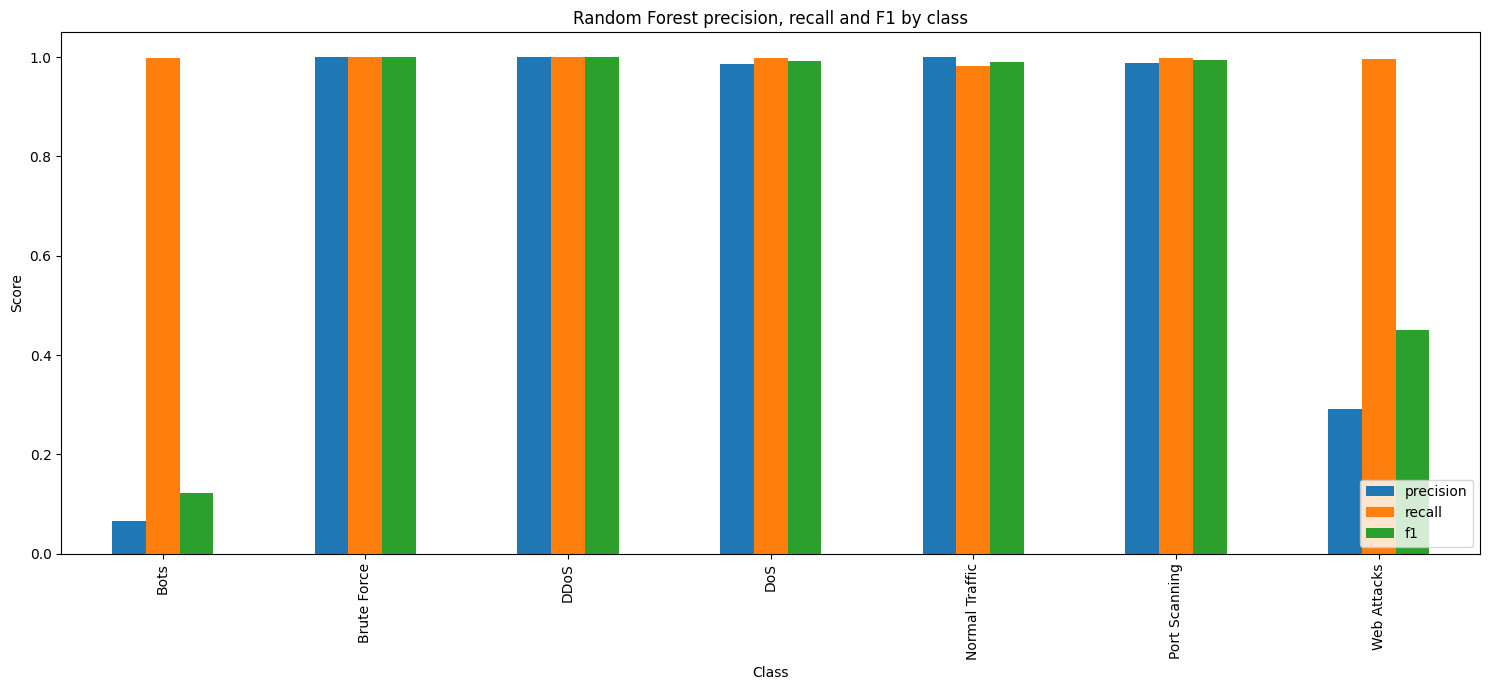

In [33]:
if not LOAD_SAVED_RESULTS_ONLY:
    metric_plot = rf_per_class.set_index("class")[
        ["precision", "recall", "f1"]
    ]

    metric_plot.plot(
        kind="bar",
        figsize=(15, 7)
    )

    plt.ylim(0, 1.05)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title("Random Forest precision, recall and F1 by class")
    plt.xticks(rotation=90)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/per_class_metrics.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


In [34]:
if not LOAD_SAVED_RESULTS_ONLY:
    cluster_source_count = train_prepared.count()

    cluster_fraction = min(
        1.0,
        CLUSTER_MAX_ROWS / float(cluster_source_count)
    )

    cluster_source = (
        train_prepared
        .select(TARGET_COL, "features")
        .sample(
            withReplacement=False,
            fraction=cluster_fraction,
            seed=SEED
        )
        .cache()
    )

    actual_cluster_rows = cluster_source.count()

    print(f"Clustering source rows: {cluster_source_count:,}")
    print(f"Clustering sample rows: {actual_cluster_rows:,}")
    print(f"Sampling fraction: {cluster_fraction:.4f}")
else:
    pass


Clustering source rows: 2,016,470
Clustering sample rows: 149,675
Sampling fraction: 0.0744


In [35]:
if not LOAD_SAVED_RESULTS_ONLY:
    pca_components = min(10, len(feature_cols))

    scaler = StandardScaler(
        inputCol="features",
        outputCol="scaled_features",
        withMean=True,
        withStd=True
    )

    scaler_model = scaler.fit(cluster_source)
    cluster_scaled = scaler_model.transform(cluster_source)

    pca = PCA(
        k=pca_components,
        inputCol="scaled_features",
        outputCol="pca_features"
    )

    pca_model = pca.fit(cluster_scaled)
    cluster_pca = pca_model.transform(cluster_scaled).cache()

    print("PCA components:", pca_components)
    print(
        "Total explained variance:",
        float(sum(pca_model.explainedVariance))
    )
else:
    pass


PCA components: 10
Total explained variance: 0.7903136327054722


,principal_component,explained_variance,cumulative_variance
0,PC1,0.276239,0.276239
1,PC2,0.111118,0.387357
2,PC3,0.077738,0.465095
3,PC4,0.058809,0.523904
4,PC5,0.055347,0.579251
5,PC6,0.048508,0.627759
6,PC7,0.046360,0.674119
7,PC8,0.042363,0.716482
8,PC9,0.039936,0.756418
9,PC10,0.033896,0.790314


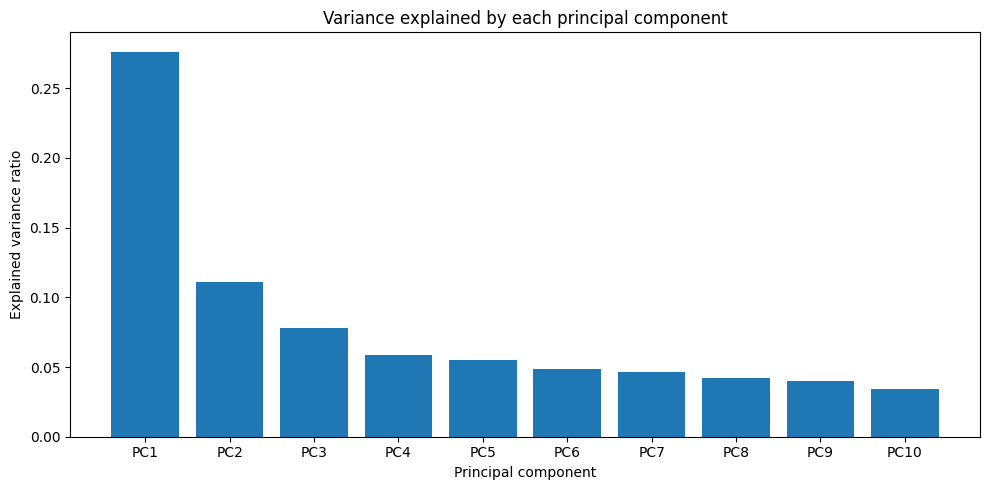

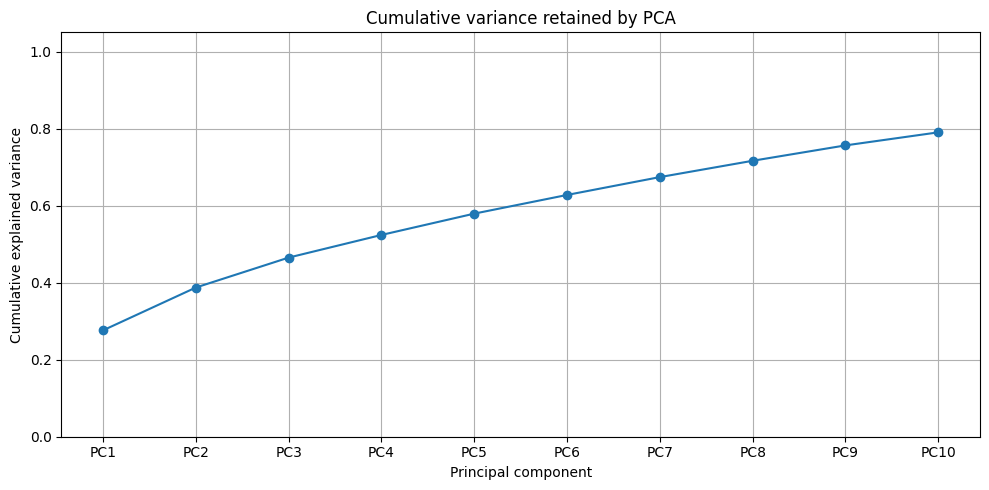

In [36]:
if not LOAD_SAVED_RESULTS_ONLY:
    pca_explained_variance = np.array(
        pca_model.explainedVariance,
        dtype=float
    )

    pca_labels = [
        f"PC{index + 1}"
        for index in range(len(pca_explained_variance))
    ]

    pca_variance_table = pd.DataFrame({
        "principal_component": pca_labels,
        "explained_variance": pca_explained_variance,
        "cumulative_variance": np.cumsum(pca_explained_variance)
    })

    display(pca_variance_table)

    plt.figure(figsize=(10, 5))
    plt.bar(
        pca_variance_table["principal_component"],
        pca_variance_table["explained_variance"]
    )
    plt.xlabel("Principal component")
    plt.ylabel("Explained variance ratio")
    plt.title("Variance explained by each principal component")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/16_pca_explained_variance.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(
        pca_variance_table["principal_component"],
        pca_variance_table["cumulative_variance"],
        marker="o"
    )
    plt.xlabel("Principal component")
    plt.ylabel("Cumulative explained variance")
    plt.title("Cumulative variance retained by PCA")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/16_pca_cumulative_variance.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    pca_variance_table.to_csv(
        f"{RESULTS_OUTPUT_PATH}/pca_explained_variance.csv",
        index=False
    )
else:
    pass


K=2: silhouette=0.9995
K=3: silhouette=0.7856
K=4: silhouette=0.5322
K=5: silhouette=0.6583
K=6: silhouette=0.6545
K=7: silhouette=0.7748
K=8: silhouette=0.4451
K=10: silhouette=0.3960


,k,silhouette
0,2,0.999535
1,3,0.785588
2,7,0.774814
3,5,0.658315
4,6,0.654532
5,4,0.532153
6,8,0.445053
7,10,0.395992


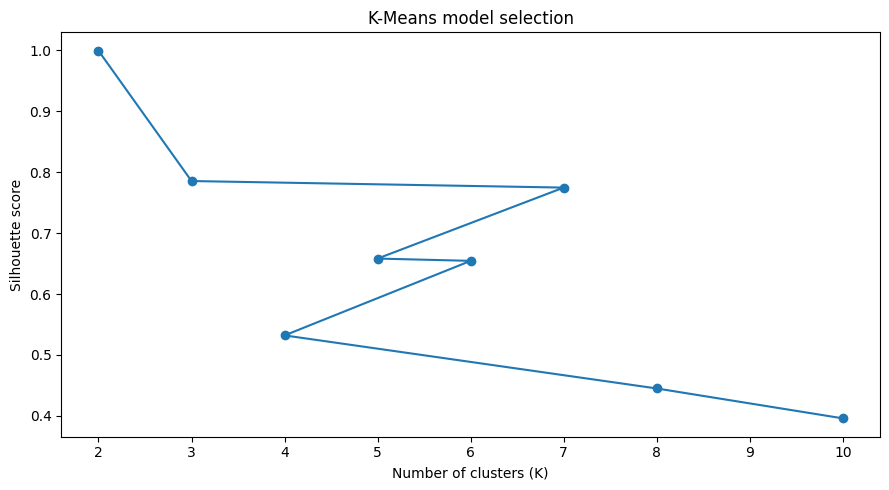

Best K: 2
Best silhouette score: 0.9995
Total K-Means search time: 308.18 seconds


In [37]:
if not LOAD_SAVED_RESULTS_ONLY:
    clustering_evaluator = ClusteringEvaluator(
        featuresCol="pca_features",
        predictionCol="cluster",
        metricName="silhouette",
        distanceMeasure="squaredEuclidean"
    )

    # Test a manageable collection of K values. Include the known number of
    # classes when it is not greater than 15.
    candidate_k_values = {
        2, 3, 4, 5, 6, 8, 10
    }

    if 2 <= number_of_labels <= 15:
        candidate_k_values.add(int(number_of_labels))

    K_CANDIDATES = sorted([
        k for k in candidate_k_values
        if k < actual_cluster_rows
    ])

    if not K_CANDIDATES:
        raise ValueError(
            "The clustering sample is too small for the candidate K values."
        )

    kmeans_search_rows = []
    best_silhouette = float("-inf")
    BEST_K = None
    kmeans_model = None

    start_time = time.time()

    for candidate_k in K_CANDIDATES:
        candidate_model = KMeans(
            k=candidate_k,
            featuresCol="pca_features",
            predictionCol="cluster",
            seed=SEED,
            maxIter=30,
            tol=1e-4
        ).fit(cluster_pca)

        candidate_predictions = candidate_model.transform(cluster_pca)

        candidate_silhouette = clustering_evaluator.evaluate(
            candidate_predictions
        )

        kmeans_search_rows.append({
            "k": int(candidate_k),
            "silhouette": float(candidate_silhouette)
        })

        print(
            f"K={candidate_k}: "
            f"silhouette={candidate_silhouette:.4f}"
        )

        if candidate_silhouette > best_silhouette:
            best_silhouette = float(candidate_silhouette)
            BEST_K = int(candidate_k)
            kmeans_model = candidate_model

    kmeans_seconds = time.time() - start_time
    silhouette_score = best_silhouette

    kmeans_search_results = (
        pd.DataFrame(kmeans_search_rows)
        .sort_values("silhouette", ascending=False)
        .reset_index(drop=True)
    )

    cluster_predictions = (
        kmeans_model
        .transform(cluster_pca)
        .cache()
    )

    display(kmeans_search_results)

    kmeans_search_results.to_csv(
        f"{RESULTS_OUTPUT_PATH}/kmeans_k_search.csv",
        index=False
    )

    plt.figure(figsize=(9, 5))
    plt.plot(
        kmeans_search_results["k"],
        kmeans_search_results["silhouette"],
        marker="o"
    )
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Silhouette score")
    plt.title("K-Means model selection")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/kmeans_k_search.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    print("Best K:", BEST_K)
    print(f"Best silhouette score: {silhouette_score:.4f}")
    print(
        "Total K-Means search time:",
        f"{kmeans_seconds:.2f} seconds"
    )
else:
    pass


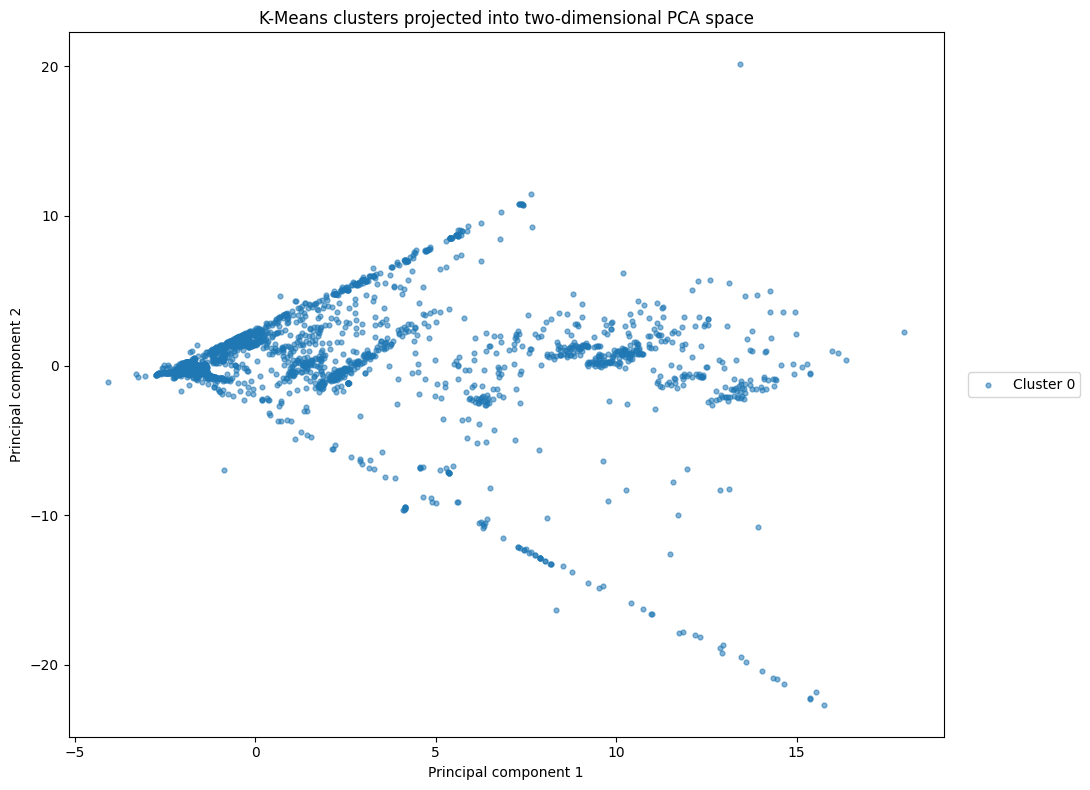

In [38]:
if not LOAD_SAVED_RESULTS_ONLY:
    pca_plot_fraction = min(
        1.0,
        PCA_VISUAL_SAMPLE_ROWS / float(max(actual_cluster_rows, 1))
    )

    pca_scatter_pd = (
        cluster_predictions
        .select(
            TARGET_COL,
            "cluster",
            vector_to_array("pca_features").alias("pca_array")
        )
        .select(
            TARGET_COL,
            "cluster",
            F.col("pca_array")[0].alias("PC1"),
            F.col("pca_array")[1].alias("PC2")
        )
        .sample(
            withReplacement=False,
            fraction=pca_plot_fraction,
            seed=SEED
        )
        .limit(PCA_VISUAL_SAMPLE_ROWS)
        .toPandas()
    )

    plt.figure(figsize=(11, 8))

    for cluster_number in sorted(pca_scatter_pd["cluster"].unique()):
        cluster_points = pca_scatter_pd[
            pca_scatter_pd["cluster"] == cluster_number
        ]

        plt.scatter(
            cluster_points["PC1"],
            cluster_points["PC2"],
            s=12,
            alpha=0.55,
            label=f"Cluster {int(cluster_number)}"
        )

    plt.xlabel("Principal component 1")
    plt.ylabel("Principal component 2")
    plt.title("K-Means clusters projected into two-dimensional PCA space")
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/17_kmeans_pca_scatter.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


+-------+--------------+------+
|cluster|Attack Type   |count |
+-------+--------------+------+
|0      |Normal Traffic|124458|
|0      |DoS           |11577 |
|0      |DDoS          |7550  |
|0      |Port Scanning |5354  |
|0      |Brute Force   |515   |
|0      |Bots          |113   |
|0      |Web Attacks   |106   |
|1      |Normal Traffic|2     |
+-------+--------------+------+



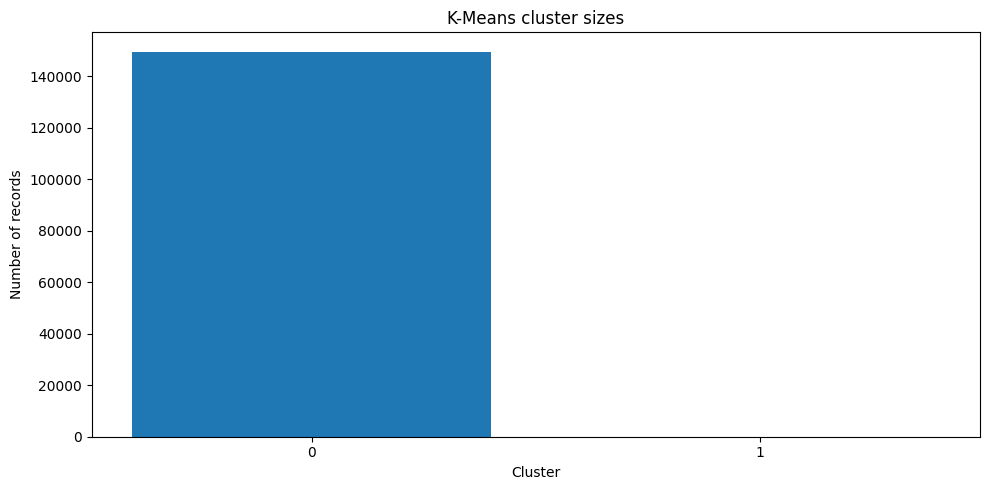

In [39]:
if not LOAD_SAVED_RESULTS_ONLY:
    cluster_class_table = (
        cluster_predictions
        .groupBy("cluster", TARGET_COL)
        .count()
        .orderBy("cluster", F.desc("count"))
    )

    cluster_class_table.show(300, truncate=False)

    cluster_class_pd = cluster_class_table.toPandas()
    cluster_class_pd.to_csv(
        f"{RESULTS_OUTPUT_PATH}/cluster_class_comparison.csv",
        index=False
    )

    cluster_size_pd = (
        cluster_predictions
        .groupBy("cluster")
        .count()
        .orderBy("cluster")
        .toPandas()
    )

    plt.figure(figsize=(10, 5))
    plt.bar(
        cluster_size_pd["cluster"].astype(str),
        cluster_size_pd["count"]
    )
    plt.xlabel("Cluster")
    plt.ylabel("Number of records")
    plt.title("K-Means cluster sizes")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/cluster_sizes.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    pass


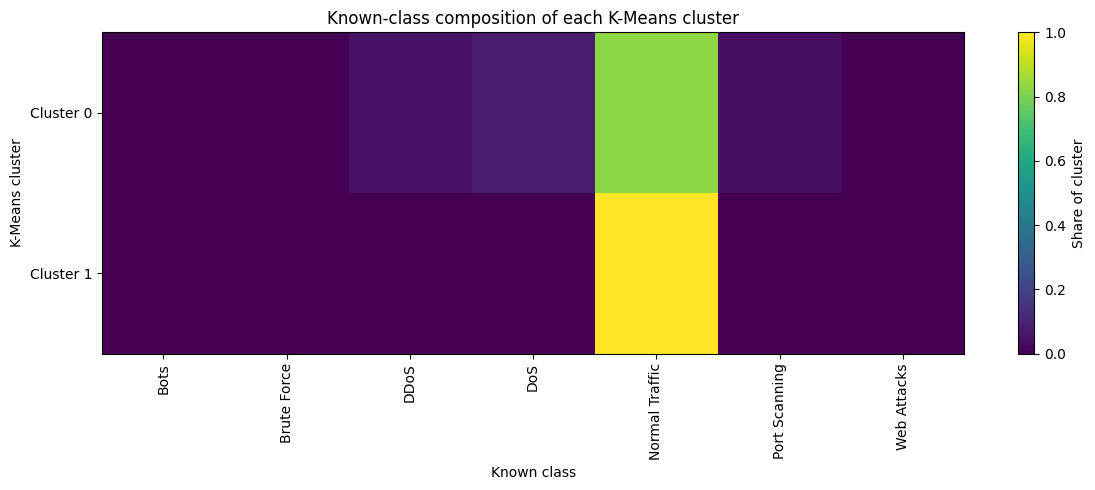

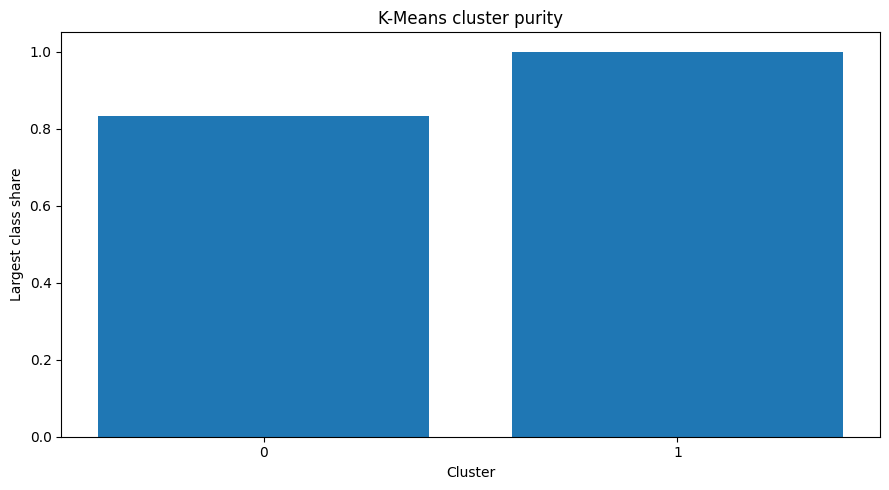

In [40]:
if not LOAD_SAVED_RESULTS_ONLY:
    cluster_class_pivot = (
        cluster_class_pd
        .pivot_table(
            index="cluster",
            columns=TARGET_COL,
            values="count",
            aggfunc="sum",
            fill_value=0
        )
        .sort_index()
    )

    cluster_class_percentage = (
        cluster_class_pivot
        .div(
            cluster_class_pivot.sum(axis=1).replace(0, np.nan),
            axis=0
        )
        .fillna(0)
    )

    plt.figure(
        figsize=(
            max(12, 0.65 * len(cluster_class_percentage.columns)),
            max(5, 0.75 * len(cluster_class_percentage.index))
        )
    )
    plt.imshow(
        cluster_class_percentage.to_numpy(),
        aspect="auto",
        vmin=0,
        vmax=1
    )
    plt.colorbar(label="Share of cluster")
    plt.xticks(
        range(len(cluster_class_percentage.columns)),
        cluster_class_percentage.columns,
        rotation=90
    )
    plt.yticks(
        range(len(cluster_class_percentage.index)),
        [
            f"Cluster {cluster_number}"
            for cluster_number in cluster_class_percentage.index
        ]
    )
    plt.xlabel("Known class")
    plt.ylabel("K-Means cluster")
    plt.title("Known-class composition of each K-Means cluster")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/18_cluster_class_heatmap.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    cluster_purity = (
        cluster_class_percentage
        .max(axis=1)
        .rename("purity")
        .reset_index()
    )

    plt.figure(figsize=(9, 5))
    plt.bar(
        cluster_purity["cluster"].astype(str),
        cluster_purity["purity"]
    )
    plt.ylim(0, 1.05)
    plt.xlabel("Cluster")
    plt.ylabel("Largest class share")
    plt.title("K-Means cluster purity")
    plt.tight_layout()
    plt.savefig(
        f"{FIGURES_DIR}/18_cluster_purity.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    cluster_class_percentage.to_csv(
        f"{RESULTS_OUTPUT_PATH}/cluster_class_percentage.csv"
    )

    cluster_purity.to_csv(
        f"{RESULTS_OUTPUT_PATH}/cluster_purity.csv",
        index=False
    )
else:
    pass


In [41]:
if not LOAD_SAVED_RESULTS_ONLY:
    # ------------------------------------------------------------------
    # Save all trained Spark models permanently.
    # ------------------------------------------------------------------
    preprocessing_model.write().overwrite().save(
        PREPROCESSING_MODEL_PATH
    )
    decision_tree_model.write().overwrite().save(
        DECISION_TREE_MODEL_PATH
    )
    best_random_forest.write().overwrite().save(
        MODEL_OUTPUT_PATH
    )
    scaler_model.write().overwrite().save(
        SCALER_MODEL_PATH
    )
    pca_model.write().overwrite().save(
        PCA_MODEL_PATH
    )
    kmeans_model.write().overwrite().save(
        KMEANS_MODEL_PATH
    )

    # ------------------------------------------------------------------
    # Save all important portable result tables.
    # ------------------------------------------------------------------
    # Define a list of (filename, variable_name, include_index_flag) tuples
    # to handle saving robustly.
    tables_to_save = [
        ("model_comparison.csv", "model_comparison", False),
        ("random_forest_tuning_results.csv", "tuning_results", False),
        ("random_forest_cv_fold_results.csv", "cv_fold_results", False),
        ("cv_mean_and_standard_deviation.csv", "cv_mean_std_table", False),
        ("random_forest_per_class_metrics.csv", "rf_per_class", False),
        ("random_forest_confusion_matrix.csv", "rf_matrix", True),
        ("feature_importance.csv", "feature_importance", False),
        ("bias_variance_analysis.csv", "bias_variance_table", False),
        ("class_distribution.csv", "class_distribution", False),
        ("missing_value_summary.csv", "missing_value_summary", False),
        ("all_feature_profile.csv", "all_feature_profile", False),
        ("all_feature_correlation.csv", "all_feature_correlation", True),
        ("class_feature_medians.csv", "class_feature_medians", True),
        ("cluster_class_comparison.csv", "cluster_class_pd", False),
        ("kmeans_k_search.csv", "kmeans_search_results", False),
        ("performance_target_check.csv", "performance_target_table", False),
        ("repeated_seed_results.csv", "repeated_results_df", False),
        ("repeated_mean_and_standard_deviation.csv", "repeated_mean_std_table", False)
    ]

    for filename, var_name, include_index in tables_to_save:
        if var_name in globals() and globals()[var_name] is not None:
            globals()[var_name].to_csv(
                f"{RESULTS_OUTPUT_PATH}/{filename}",
                index=include_index
            )
        else:
            print(f"Skipping saving '{filename}': variable '{var_name}' not found or is None.")

    # ------------------------------------------------------------------
    # Save metadata required for a complete reload.
    # ------------------------------------------------------------------
    experiment_configuration = {
        "dataset_path_used": DATA_PATH,
        "persistent_dataset_path": PERSISTENT_DATA_PATH,
        "target_column": TARGET_COL,
        "seed": SEED,
        "train_ratio": TRAIN_RATIO,
        "test_ratio": TEST_RATIO,
        "cv_requested_folds": CV_FOLDS,
        "cv_effective_folds": EFFECTIVE_CV_FOLDS,
        "cv_max_rows": CV_MAX_ROWS,
        "number_of_features": len(feature_cols),
        "feature_columns": feature_cols,
        "number_of_classes": number_of_labels,
        "class_names": label_names,
        "best_num_trees": BEST_NUM_TREES,
        "best_max_depth": BEST_MAX_DEPTH,
        "best_min_instances_per_node": BEST_MIN_INSTANCES,
        "best_subsampling_rate": BEST_SUBSAMPLING_RATE,
        "best_max_bins": BEST_MAX_BINS,
        "best_kmeans_k": int(BEST_K),
        "dataset_title": DATASET_TITLE,
        "dataset_source_url": DATASET_SOURCE_URL,
        "dataset_download_date": DATASET_DOWNLOAD_DATE,
        "dataset_size_mb": float(dataset_size_mb),
        "spark_version": spark.version,
        "python_version": platform.python_version()
    }

    saved_at = datetime.now(timezone.utc).isoformat()

    def json_safe_summary(summary_dictionary):
        output = {}
        for key, value in summary_dictionary.items():
            if isinstance(value, (int, float, np.integer, np.floating)):
                output[key] = float(value)
            else:
                output[key] = value
        return output

    experiment_summary = {
        "saved_at": saved_at,
        "cleaned_rows": int(cleaned_row_count),
        "number_of_features": int(len(feature_cols)),
        "number_of_classes": int(number_of_labels),
        "decision_tree_summary": json_safe_summary(dt_summary),
        "random_forest_summary": json_safe_summary(rf_summary),
        "cv_mean_std": cv_mean_std_table.to_dict(orient="records"),
        "best_kmeans_k": int(BEST_K),
        "kmeans_silhouette": float(silhouette_score),
        "kmeans_seconds": float(kmeans_seconds)
    }

    all_saved_figures = sorted(
        glob.glob(f"{FIGURES_DIR}/**/*.png", recursive=True)
    )

    figure_manifest = {
        "created_at": saved_at,
        "figure_count": len(all_saved_figures),
        "figures": [
            os.path.relpath(path, PROJECT_ROOT)
            for path in all_saved_figures
        ]
    }

    with open(
        EXPERIMENT_CONFIGURATION_PATH,
        "w",
        encoding="utf-8"
    ) as configuration_file:
        json.dump(experiment_configuration, configuration_file, indent=2)

    with open(
        EXPERIMENT_SUMMARY_PATH,
        "w",
        encoding="utf-8"
    ) as summary_file:
        json.dump(experiment_summary, summary_file, indent=2)

    with open(
        FIGURE_MANIFEST_PATH,
        "w",
        encoding="utf-8"
    ) as manifest_file:
        json.dump(figure_manifest, manifest_file, indent=2)

    readme_text = f"""
    CN7030 COURSEWORK 2 \u2014 SAVED PROJECT

    Saved at: {saved_at}
    Dataset: {DATASET_TITLE}
    Target: {TARGET_COL}
    Cleaned rows: {cleaned_row_count}
    Usable numerical features: {len(feature_cols)}
    Classes: {number_of_labels}

    BEST RANDOM FOREST
    Trees: {BEST_NUM_TREES}
    Depth: {BEST_MAX_DEPTH}
    Minimum instances per node: {BEST_MIN_INSTANCES}
    Subsampling rate: {BEST_SUBSAMPLING_RATE}
    Maximum bins: {BEST_MAX_BINS}
    Test weighted F1: {rf_summary['weighted_f1']:.6f}

    RELOAD
    Open the notebook, set PROJECT_MODE = \"LOAD\", and run all cells.
    Training sections will be skipped automatically.

    FOLDERS
    Data: {DATA_DIR}
    Models: {MODELS_DIR}
    Results: {RESULTS_OUTPUT_PATH}
    Figures: {FIGURES_DIR}
    Metadata: {METADATA_DIR}
    """.strip()

    with open(README_PATH, "w", encoding="utf-8") as readme_file:
        readme_file.write(readme_text + "\n")

    # Write the success marker last. Its presence means all previous saves worked.
    with open(
        SUCCESS_MARKER_PATH,
        "w",
        encoding="utf-8"
    ) as marker_file:
        marker_file.write(
            "CN7030 training and result saving completed successfully.\n"
            f"Saved at: {saved_at}\n"
        )

    print("=" * 76)
    print("FULL PROJECT SAVED PERMANENTLY")
    print("=" * 76)
    print("Project folder:", PROJECT_ROOT)
    print("Persistent data:", PERSISTENT_DATA_PATH)
    print("Models folder:", MODELS_DIR)
    print("Results folder:", RESULTS_OUTPUT_PATH)
    print("Figures folder:", FIGURES_DIR)
    print("All-feature figures:", ALL_FEATURE_FIGURES_DIR)
    print("Saved figure count:", len(all_saved_figures))
    print("Completion marker:", SUCCESS_MARKER_PATH)
    print("=" * 76)
    print(
        "To reload without training, set PROJECT_MODE='LOAD' "
        "and run the notebook from the first cell."
    )
else:
    pass

Skipping saving 'feature_importance.csv': variable 'feature_importance' not found or is None.
Skipping saving 'bias_variance_analysis.csv': variable 'bias_variance_table' not found or is None.
Skipping saving 'missing_value_summary.csv': variable 'missing_value_summary' not found or is None.
Skipping saving 'all_feature_profile.csv': variable 'all_feature_profile' not found or is None.
Skipping saving 'all_feature_correlation.csv': variable 'all_feature_correlation' not found or is None.
Skipping saving 'class_feature_medians.csv': variable 'class_feature_medians' not found or is None.
Skipping saving 'performance_target_check.csv': variable 'performance_target_table' not found or is None.
Skipping saving 'repeated_seed_results.csv': variable 'repeated_results_df' not found or is None.
Skipping saving 'repeated_mean_and_standard_deviation.csv': variable 'repeated_mean_std_table' not found or is None.
FULL PROJECT SAVED PERMANENTLY
Project folder: /content/drive/MyDrive/CN7030_CourseWor

In [42]:
print("=" * 72)
print("CN7030 FINAL RESULT SUMMARY")
print("=" * 72)

if LOAD_SAVED_RESULTS_ONLY:
    summary_cleaned_rows = int(saved_summary["cleaned_rows"])
else:
    summary_cleaned_rows = int(cleaned_row_count)

print(f"Dataset rows after cleaning: {summary_cleaned_rows:,}")
print(f"Number of numerical features: {len(feature_cols)}")
print(f"Number of classes: {number_of_labels}")
print(f"Best Random Forest trees: {BEST_NUM_TREES}")
print(f"Best Random Forest depth: {BEST_MAX_DEPTH}")
print(f"Best minimum node instances: {BEST_MIN_INSTANCES}")
print(f"Best subsampling rate: {BEST_SUBSAMPLING_RATE}")
print(f"Test accuracy: {rf_summary['accuracy']:.4f}")
print(f"Test weighted F1: {rf_summary['weighted_f1']:.4f}")
print(f"Test macro F1: {rf_summary['macro_f1']:.4f}")
print(f"Best K-Means K: {BEST_K}")
print(f"K-Means silhouette: {silhouette_score:.4f}")

if "cv_mean_std_table" in globals() and cv_mean_std_table is not None:
    print("\nCross-validation mean ± standard deviation:")
    for row in cv_mean_std_table.itertuples(index=False):
        print(f"  {row.metric}: {row.report_format}")

if (
    RUN_REPEATED_EVALUATION
    and "repeated_mean_std_table" in globals()
    and repeated_mean_std_table is not None
):
    print("\nOptional repeated full-run evaluation:")
    for row in repeated_mean_std_table.itertuples(index=False):
        print(f"  {row.metric}: {row.report_format}")

print("=" * 72)
print("Permanent saved project:", PROJECT_ROOT)
print("Saved successfully:", os.path.exists(SUCCESS_MARKER_PATH))

CN7030 FINAL RESULT SUMMARY
Dataset rows after cleaning: 2,520,590
Number of numerical features: 52
Number of classes: 7
Best Random Forest trees: 40
Best Random Forest depth: 12
Best minimum node instances: 2
Best subsampling rate: 0.8
Test accuracy: 0.9852
Test weighted F1: 0.9906
Test macro F1: 0.7929
Best K-Means K: 2
K-Means silhouette: 0.9995

Cross-validation mean ± standard deviation:
  cross_validation_accuracy: 0.9937 ± 0.0004
  cross_validation_weighted_f1: 0.9938 ± 0.0004
Permanent saved project: /content/drive/MyDrive/CN7030_CourseWork2
Saved successfully: True


,result,score
0,Decision Tree,0.995874
1,Random Forest,0.990599
2,K-Means,0.999535


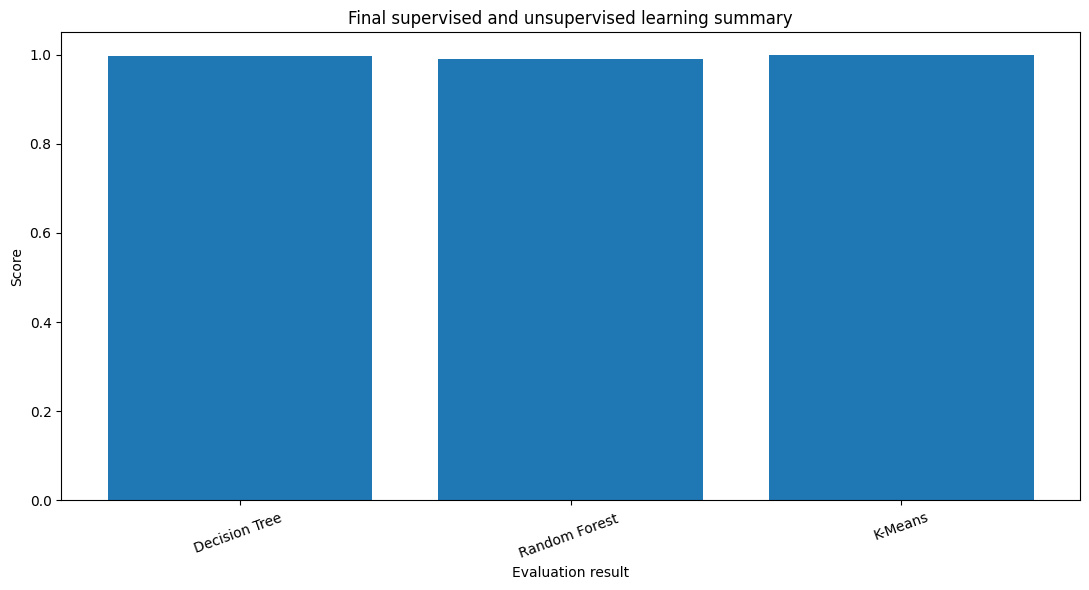

All figures are stored in:
/content/drive/MyDrive/CN7030_CourseWork2/figures


In [43]:
final_visual_summary = pd.DataFrame({
    "result": [
        "Decision Tree ",
        "Random Forest ",
        "K-Means"
    ],
    "score": [
        dt_summary["weighted_f1"],
        rf_summary["weighted_f1"],
        silhouette_score
    ]
})

display(final_visual_summary)

figure, axis = plt.subplots(figsize=(11, 6))
axis.bar(
    final_visual_summary["result"],
    final_visual_summary["score"]
)
axis.set_xlabel("Evaluation result")
axis.set_ylabel("Score")
axis.set_title("Final supervised and unsupervised learning summary")
axis.set_ylim(
    min(0, final_visual_summary["score"].min() - 0.05),
    1.05
)
axis.tick_params(axis="x", rotation=20)
figure.tight_layout()

final_summary_figure_path = (
    f"{FIGURES_DIR}/19_final_project_summary.png"
)
figure.savefig(
    final_summary_figure_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close(figure)

print("All figures are stored in:")
print(FIGURES_DIR)

In [44]:
# Save a copy of this notebook in Google Drive first, then update this
# path if your Drive folder is different.
NOTEBOOK_TO_EXPORT = (
    "/content/drive/MyDrive/"
    "Group_10_CRWK_CN7030_4.ipynb"
)

# Replace XX with the real group number and member count.
HTML_BASENAME = "Group_10_CRWK_CN7030_4"
HTML_OUTPUT_DIRECTORY = PROJECT_ROOT

print("Notebook expected at:", NOTEBOOK_TO_EXPORT)
print("HTML will be written to:", HTML_OUTPUT_DIRECTORY)
print("Final HTML name:", HTML_BASENAME + ".html")

print("\nRun this command after the notebook file exists:")
print(
    f'jupyter nbconvert --to html "{NOTEBOOK_TO_EXPORT}" '
    f'--output "{HTML_BASENAME}" '
    f'--output-dir "{HTML_OUTPUT_DIRECTORY}"'
)

# Executable Colab form:
# !jupyter nbconvert --to html "$NOTEBOOK_TO_EXPORT" \
#     --output "$HTML_BASENAME" \
#     --output-dir "$HTML_OUTPUT_DIRECTORY"

Notebook expected at: /content/drive/MyDrive/Group_10_CRWK_CN7030_4.ipynb
HTML will be written to: /content/drive/MyDrive/CN7030_CourseWork2
Final HTML name: Group_10_CRWK_CN7030_4.html

Run this command after the notebook file exists:
jupyter nbconvert --to html "/content/drive/MyDrive/Group_10_CRWK_CN7030_4.ipynb" --output "Group_10_CRWK_CN7030_4" --output-dir "/content/drive/MyDrive/CN7030_CourseWork2"


In [45]:

HTML_OUTPUT_DIRECTORY = PROJECT_ROOT

print('Converting notebook to HTML...')
!jupyter nbconvert --to html "$NOTEBOOK_TO_EXPORT" \
    --output "$HTML_BASENAME" \
    --output-dir "$HTML_OUTPUT_DIRECTORY"

print(f'Successfully converted to HTML and saved as {HTML_OUTPUT_DIRECTORY}/{HTML_BASENAME}.html')

Converting notebook to HTML...
[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Group_10_CRWK_CN7030_4.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting